In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm

# EDA

In [ ]:
df=pd.read_csv('data.csv')


In [ ]:
df.columns=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

In [ ]:
df=df.replace(' ?', np.nan).dropna()

In [ ]:
df['fnlwgt'].describe()

,fnlwgt
count,3.016100e+04
mean,1.897976e+05
std,1.056527e+05
min,1.376900e+04
25%,1.176280e+05
50%,1.784290e+05
75%,2.376300e+05
max,1.484705e+06


In [ ]:
df['fnlwgt'].value_counts()

,count
fnlwgt,
203488,13
148995,12
121124,12
113364,12
123011,12
...,...
192965,1
514716,1
42972,1


In [ ]:
len(df.fnlwgt.unique())

20262

In [ ]:
df[df.fnlwgt == 203488]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
3463,31,Private,203488,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,7298,0,50,United-States,>50K
9022,30,Private,203488,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
10382,33,Private,203488,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,United-States,<=50K
10765,34,Private,203488,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
17552,30,Private,203488,Some-college,10,Never-married,Craft-repair,Not-in-family,White,Male,0,0,44,United-States,<=50K
17792,31,Private,203488,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K
18915,31,Self-emp-inc,203488,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,>50K
20312,33,Private,203488,Some-college,10,Never-married,Exec-managerial,Own-child,White,Male,0,0,45,United-States,<=50K
22522,34,Private,203488,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
22722,34,Private,203488,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,15024,0,40,United-States,>50K


In [ ]:
df['count_people']=(df['fnlwgt']/df['fnlwgt'].sum()*340000000).apply(int)


Восстановим абсолютные значения из данных пропорций. Берется конкретное значение fnlwgt и делится на сумму столбца fnlwgt (то есть все веса). Получаем долю конкретной группы от всех весов. Умнажаем долю обратно на реальное колво граждан сша (340млн человек), и получаем абсолютное зyfчение реальных американцев конкретной группы (мин = около 800, макс около 9000).

Конкретный пример: возьмем 27летних черных незамужних женщин сварщиков, пускай их вес в нашем дф составил 30 000 => получим долю: 30 000/5724484103* =5,24*10^(-6). из доли обратно в реальное колво людей: 5,24*10^(-6)*340 000 000=1781 реальных вот этих черных женцин.

как это выглядит от обратного: было нное колво людей из них сделали долю, поделив на колво американцев. позже чтобы эта доля нормально выглядела в дф умножается на большое число, чтобы оно стало хотябы больше 1, и даже чем больше тем точнее, вот как раз 10к-100к. вот так и получились значения fnlwgt.


*df['fnlwgt'].sum() та сумма весов

                                                      Описание признаков
age - возраст

workclass - правовой статус занятости человека. Правительство(локальное/муниципальное/федеральное), самозанятый(трудоустроенный в организацию/не трудоустроенный), в том числе не раскрывающие данную информацию лица.

fnlwgt - final weight - уровень репрезентативности человека

education - финальная ступень образования

education-num - кодировка ступени образования

marital-status - семейное положение(раздельный быт/развод/совместная жизнь/овдовлён)

occupation - профессия, сфера трудовой деятельности

relationship - статус семейной жизни (муж/жена, есть ли ребёнок, состоит ли в семье)


race - раса (Белые, чёрные, лица азиатского происхождения, лица индейского происхождения(в тч эскимосы))

sex - пол

capital gain - прирост к годовому заработку

capital loss - понижение годовому заработку

hours-per-week - количество рабочих часов в неделю

native-country - страна происхождения респондента

income - целевая метрика, которая делит респондентов на две группы

In [ ]:
df.workclass = df.workclass.str.strip()
df.education = df.education.str.strip()
df['marital-status'] = df['marital-status'].str.strip()
df.occupation = df.occupation.str.strip()
df.relationship = df.relationship.str.strip()
df.race = df.race.str.strip()
df.sex = df.sex.str.strip()
df['native-country'] = df['native-country'].str.strip()
df.income = df.income.str.strip()

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,count_people
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,4948
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,12808
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,13941
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,20099
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,16902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,15282
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,9168
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,9022
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,11967


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,count_people
count,30138.000000,3.013800e+04,30138.000000,30138.000000,30138.000000,30138.000000,30138.000000
mean,38.441702,1.897988e+05,10.122437,1092.805329,88.442863,40.934734,11272.407359
std,13.131643,1.056584e+05,2.548727,7409.230902,404.451628,11.978951,6275.475722
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000,817.000000
25%,28.000000,1.176295e+05,9.000000,0.000000,0.000000,40.000000,6986.000000
50%,37.000000,1.784190e+05,10.000000,0.000000,0.000000,40.000000,10596.500000
75%,47.000000,2.376062e+05,13.000000,0.000000,0.000000,45.000000,14112.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,88182.000000


In [ ]:
df[df['workclass']=='Self-emp-not-inc']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,count_people
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,4948
6,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K,12451
15,25,Self-emp-not-inc,176756,HS-grad,9,Never-married,Farming-fishing,Own-child,White,Male,0,0,35,United-States,<=50K,10498
18,43,Self-emp-not-inc,292175,Masters,14,Divorced,Exec-managerial,Unmarried,White,Female,0,0,45,United-States,>50K,17353
38,48,Self-emp-not-inc,265477,Assoc-acdm,12,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K,15767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32454,36,Self-emp-not-inc,109133,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,>50K,6481
32455,30,Self-emp-not-inc,261943,11th,7,Married-spouse-absent,Craft-repair,Not-in-family,White,Male,0,0,30,Honduras,<=50K,15557
32467,39,Self-emp-not-inc,193689,HS-grad,9,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,65,United-States,<=50K,11503
32547,65,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K,5901


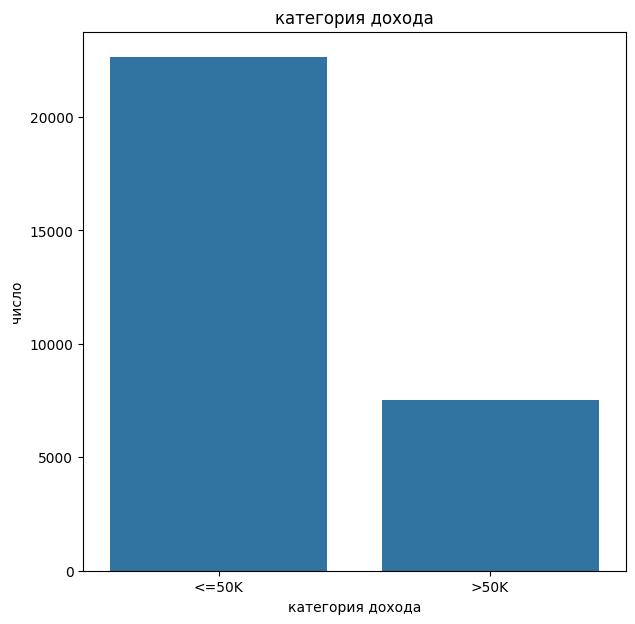

In [ ]:
plt.figure(figsize=(7,7))
sns.countplot(df, x="income")
plt.title("категория дохода")
plt.xlabel("категория дохода")
plt.ylabel("число")
plt.show()

In [ ]:
df['relationship'].unique()

array(['Husband', 'Not-in-family', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

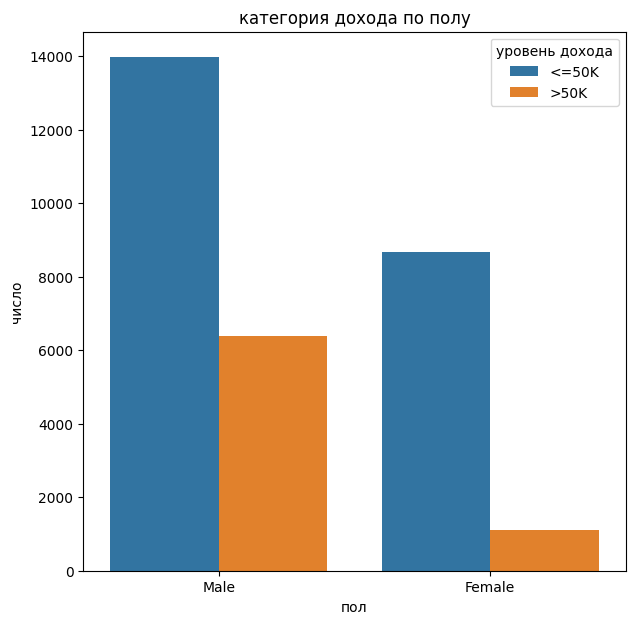

In [ ]:
plt.figure(figsize=(7,7))
sns.countplot(df, x="sex", hue="income")
plt.title("категория дохода по полу")
plt.xlabel("пол")
plt.ylabel("число")
plt.legend(title="уровень дохода")
plt.show()

In [ ]:
df[df.income == '<=50K'].shape[0]/df.shape[0]

0.7509456500099542

In [ ]:
df[df.income == '>50K'].shape[0]/df.shape[0]

0.24905434999004578

~ 25% - >50k

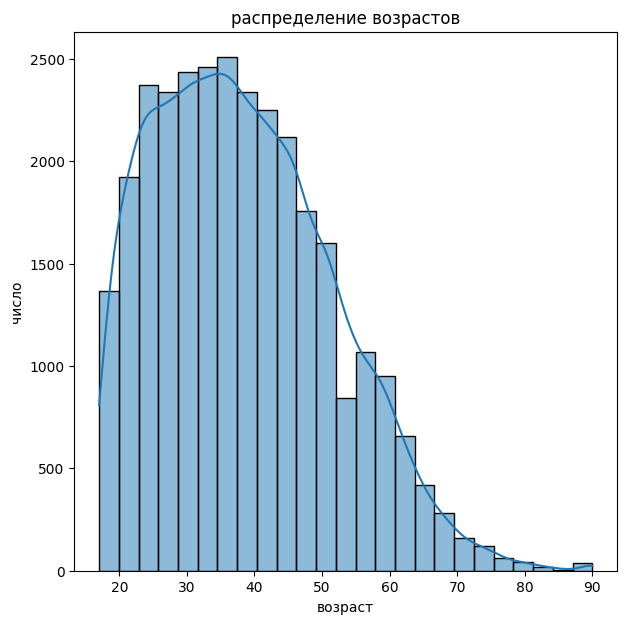

In [ ]:
plt.figure(figsize=(7,7))
sns.histplot(data=df, x="age", bins=25, kde=True)
plt.title("распределение возрастов")
plt.xlabel("возраст")
plt.ylabel("число")
plt.show()

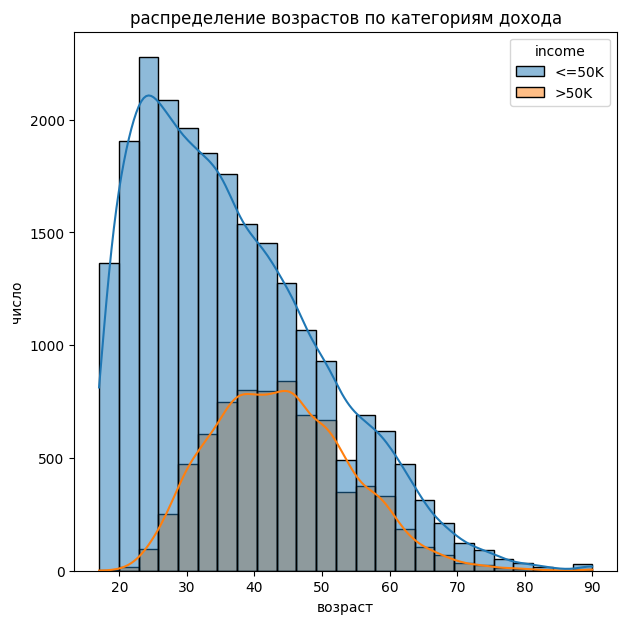

In [ ]:
plt.figure(figsize=(7, 7))
sns.histplot(data=df, x="age", hue="income", bins=25, kde=True)
plt.title("распределение возрастов по категориям дохода")
plt.xlabel("возраст")
plt.ylabel("число")
plt.show()

In [ ]:
df.education.unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', '7th-8th', 'Doctorate', 'Assoc-voc', 'Prof-school',
       '5th-6th', '10th', 'Preschool', '12th', '1st-4th'], dtype=object)

In [ ]:
df.groupby('education-num')['education'].value_counts().sort_index()

,,count
education-num,education,
1,Preschool,44
2,1st-4th,149
3,5th-6th,287
4,7th-8th,556
5,9th,455
6,10th,820
7,11th,1048
8,12th,377
9,HS-grad,9834


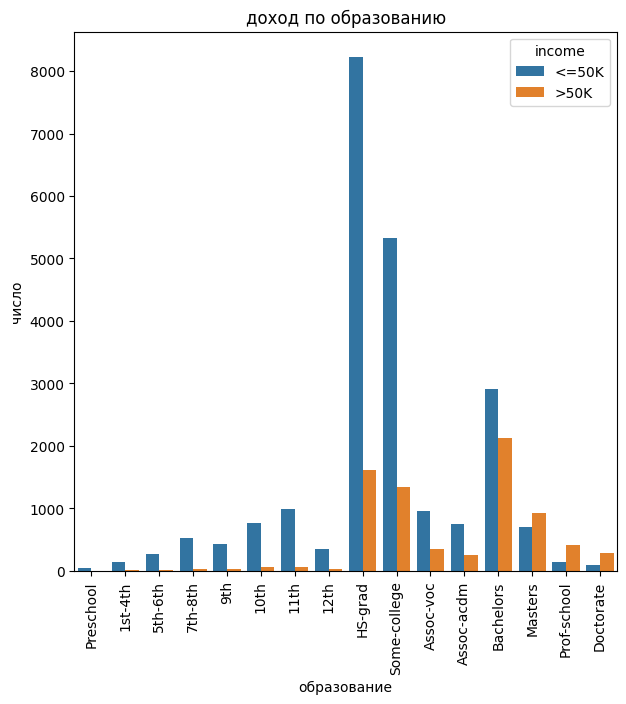

In [ ]:
plt.figure(figsize=(7,7))
order = ['Preschool',
         '1st-4th',
         '5th-6th',
         '7th-8th',
         '9th',
         '10th',
         '11th',
         '12th',
         'HS-grad',
         'Some-college',
         'Assoc-voc',
         'Assoc-acdm',
         'Bachelors',
         'Masters',
         'Prof-school',
         'Doctorate']

sns.countplot(data= df, x='education', hue= 'income', order= order)
plt.title('доход по образованию')
plt.xticks(rotation = 90)
plt.xlabel('образование')
plt.ylabel('число')
plt.show()

In [ ]:
def age_group(x):
    x = int(x)
    x = abs(x)
    if( 16 < x < 31 ):
        return "17-30"
    if( 30 < x < 41 ):
        return "31-40"
    if( 40 < x < 51 ):
        return "41-50"
    if( 50 < x < 61 ):
        return "51-60"
    if( 60 < x < 71 ):
        return "61-70"
    else:
        return "Greater than 70"

df['age_group'] = df['age'].apply(age_group)

/tmp/ipython-input-7062504.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = df['age'].apply(age_group)


In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,count_people,age_group
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,4948,41-50
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,12808,31-40
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,13941,51-60
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,20099,17-30
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,16902,31-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,15282,17-30
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,9168,31-40
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,9022,51-60
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,11967,17-30


<Axes: xlabel='age_group', ylabel='count'>

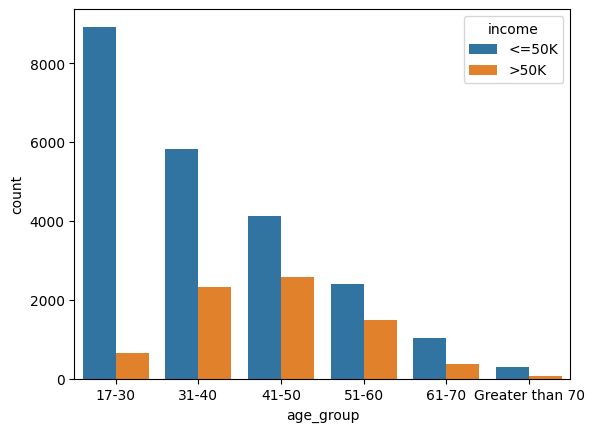

In [ ]:
order_list = ['17-30', '31-40', '41-50', '51-60', '61-70', 'Greater than 70']
sns.countplot(x='age_group', hue='income', data=df, order=order_list)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Self-emp-not-inc'),
  Text(1, 0, 'Private'),
  Text(2, 0, 'State-gov'),
  Text(3, 0, 'Federal-gov'),
  Text(4, 0, 'Local-gov'),
  Text(5, 0, 'Self-emp-inc'),
  Text(6, 0, 'Without-pay')])

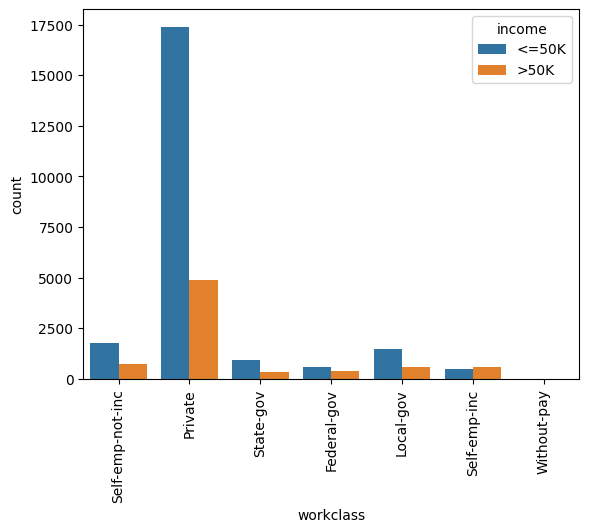

In [ ]:
sns.countplot(x='workclass', hue='income', data=df)
plt.xticks(rotation = 90)


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Married-civ-spouse'),
  Text(1, 0, 'Divorced'),
  Text(2, 0, 'Married-spouse-absent'),
  Text(3, 0, 'Never-married'),
  Text(4, 0, 'Separated'),
  Text(5, 0, 'Married-AF-spouse'),
  Text(6, 0, 'Widowed')])

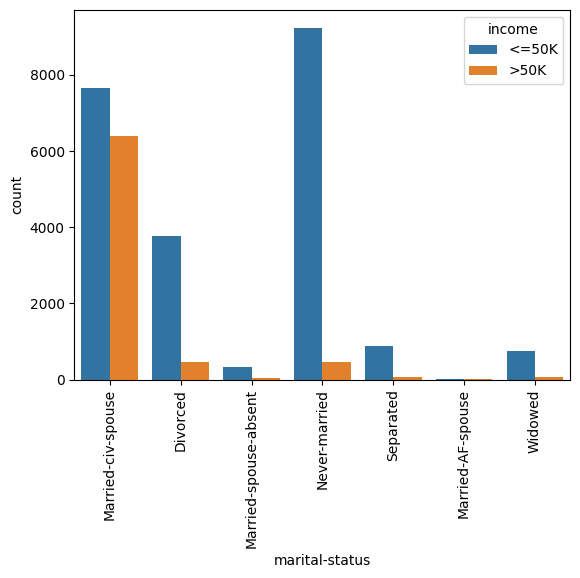

In [ ]:
sns.countplot(x='marital-status', hue ='income', data=df)
plt.xticks(rotation = 90)



([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Husband'),
  Text(1, 0, 'Not-in-family'),
  Text(2, 0, 'Wife'),
  Text(3, 0, 'Own-child'),
  Text(4, 0, 'Unmarried'),
  Text(5, 0, 'Other-relative')])

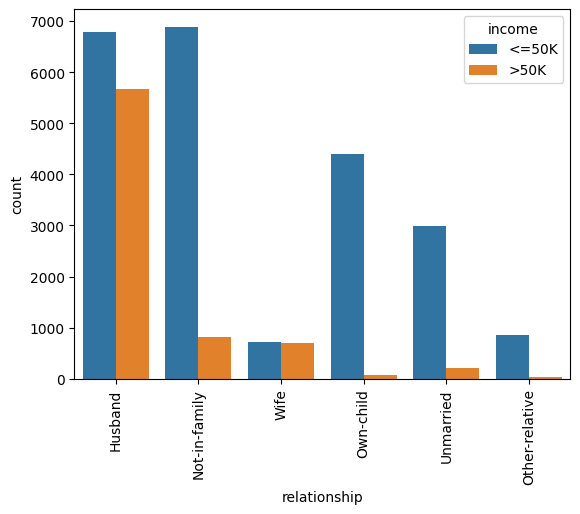

In [ ]:
sns.countplot(x='relationship', hue ='income', data=df)
plt.xticks(rotation = 90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Exec-managerial'),
  Text(1, 0, 'Handlers-cleaners'),
  Text(2, 0, 'Prof-specialty'),
  Text(3, 0, 'Other-service'),
  Text(4, 0, 'Adm-clerical'),
  Text(5, 0, 'Sales'),
  Text(6, 0, 'Transport-moving'),
  Text(7, 0, 'Farming-fishing'),
  Text(8, 0, 'Machine-op-inspct'),
  Text(9, 0, 'Tech-support'),
  Text(10, 0, 'Craft-repair'),
  Text(11, 0, 'Protective-serv'),
  Text(12, 0, 'Armed-Forces'),
  Text(13, 0, 'Priv-house-serv')])

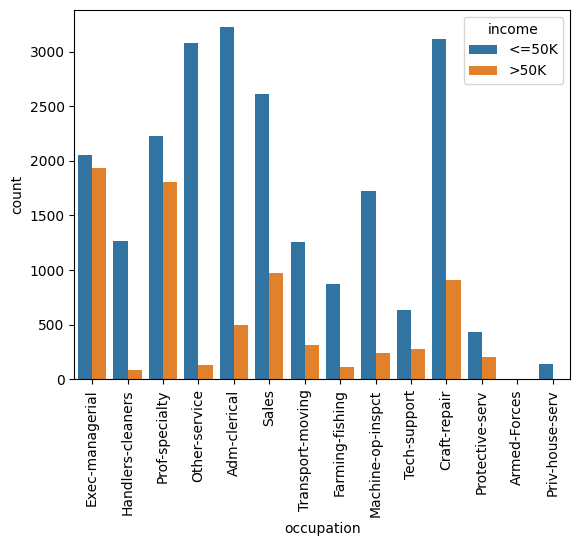

In [ ]:
sns.countplot(x='occupation', hue = 'income', data=df)
plt.xticks(rotation = 90)



<Axes: xlabel='capital-gain', ylabel='count'>

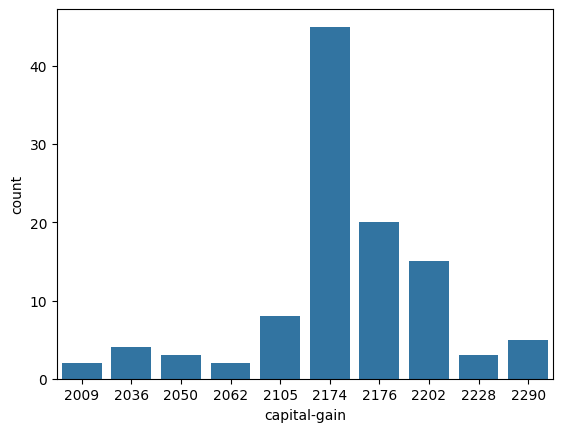

In [ ]:
filtered_df = df[(df['capital-gain'] <= 2300)&(df['capital-gain'] > 2000)]

sns.countplot(filtered_df, x="capital-gain")


# СМОТРИМ НА ЧАСЫ РАБОТЫ (АМАНЯША)

сначала посмотрим, представители каких профессий представлены и с какими долями

In [ ]:
df.occupation.unique()

array(['Exec-managerial', 'Handlers-cleaners', 'Prof-specialty',
       'Other-service', 'Adm-clerical', 'Sales', 'Transport-moving',
       'Farming-fishing', 'Machine-op-inspct', 'Tech-support',
       'Craft-repair', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [ ]:
occ_pop = (df.groupby('occupation')['count_people'].sum().sort_values(ascending=False))
occ_share = occ_pop / df['count_people'].sum()
occ_share.head(10)

,count_people
occupation,
Craft-repair,0.135377
Prof-specialty,0.130474
Exec-managerial,0.128731
Adm-clerical,0.124804
Sales,0.119636
Other-service,0.105691
Machine-op-inspct,0.067009
Transport-moving,0.052265
Handlers-cleaners,0.048010


выберем наиболее релевантные для нас профф области

In [ ]:
relevant_occupations = [
    'Exec-managerial',
    'Prof-specialty',
    'Sales',
    'Adm-clerical',
    'Tech-support'
]

In [ ]:
rel_occ_pop = df[df['occupation'].isin(relevant_occupations)]

rel_share = rel_occ_pop['count_people'].sum()/df['count_people'].sum()
rel_share

np.float64(0.5341739535467471)

Проведем анализ ступеней образования

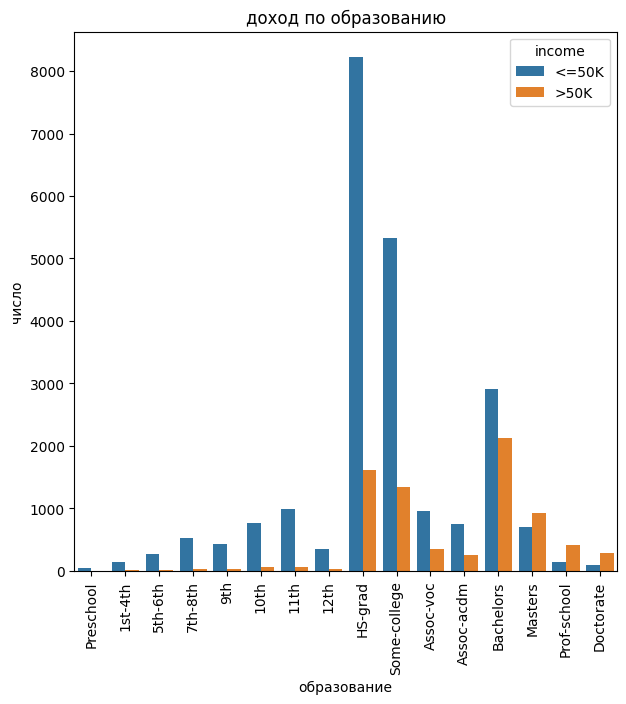

In [ ]:
plt.figure(figsize=(7, 7))
order = ['Preschool',
         '1st-4th',
         '5th-6th',
         '7th-8th',
         '9th',
         '10th',
         '11th',
         '12th',
         'HS-grad',
         'Some-college',
         'Assoc-voc',
         'Assoc-acdm',
         'Bachelors',
         'Masters',
         'Prof-school',
         'Doctorate']

sns.countplot(data= df, x='education', hue= 'income', order= order)
plt.title('доход по образованию')
plt.xticks(rotation = 90)
plt.xlabel('образование')
plt.ylabel('число')
plt.show()

In [ ]:
edu_share = (df.groupby("education")["count_people"].sum().reset_index(name="people_count"))

edu_share["share"] = edu_share["people_count"] / edu_share["people_count"].sum()

edu_share.sort_values("share", ascending=False)


,education,people_count,share
11,HS-grad,110610349,0.325585
15,Some-college,74937053,0.220580
9,Bachelors,56254516,0.165587
12,Masters,17376157,0.051147
8,Assoc-voc,14060881,0.041389
1,11th,12029541,0.035409
7,Assoc-acdm,11543233,0.033978
0,10th,9592617,0.028236
5,7th-8th,6313707,0.018585
14,Prof-school,5975165,0.017588


Самые многочисленные категории - HS-grad, Some-college, Bachelors, Masters

Рассмотрим категории, где процент высокого дохода максимален

In [ ]:
df1 = df.copy()

df1["high_income"] = (df1["income"] == ">50K").astype(int)

edu = (df1.groupby("education").apply(lambda x: (x["count_people"] * x["high_income"]).sum() / x["count_people"].sum()).reset_index(name='high_income_share'))

edu.sort_values("high_income_share", ascending=False)


/tmp/ipython-input-4260073732.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  edu = (df1.groupby("education").apply(lambda x: (x["count_people"] * x["high_income"]).sum() / x["count_people"].sum()).reset_index(name='high_income_share'))


,education,high_income_share
10,Doctorate,0.764337
14,Prof-school,0.748425
12,Masters,0.569366
9,Bachelors,0.425067
8,Assoc-voc,0.264967
7,Assoc-acdm,0.252730
15,Some-college,0.206516
11,HS-grad,0.160914
2,12th,0.082142
0,10th,0.072770


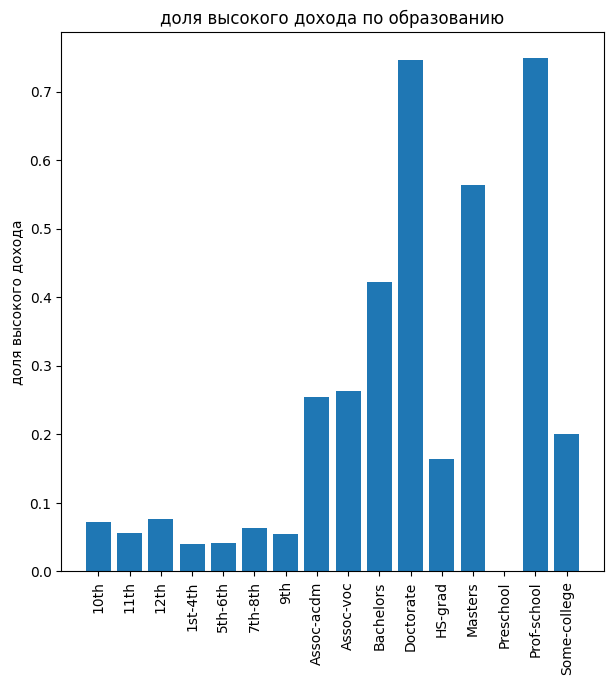

In [ ]:
plt.figure(figsize=(7, 7))
plt.bar(edu["education"], edu["high_income_share"])
plt.xticks(rotation=90)
plt.ylabel("доля высокого дохода")
plt.title("доля высокого дохода по образованию")
plt.show()

Видим, что больше всего людей с высоким заработком в процентном соотношении представлено в категориях Doctorate, Prof-school, Masters, Bachelors

можем заметить, что среди наиболее "популярных" степеней образования и лидеров по заработку встречаются Bachelors и masters

Рассмотрим еще, сколько работает каждая категория в среднем

In [ ]:
hours_weighted = (df1.groupby(["education", "high_income"])
       .apply(lambda x: (x["hours-per-week"] * x["count_people"]).sum() / x["count_people"].sum())
      .reset_index(name="avg_hours"))

hours_weighted

/tmp/ipython-input-406220163.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["hours-per-week"] * x["count_people"]).sum() / x["count_people"].sum())


,education,high_income,avg_hours
0,10th,0,36.932023
1,10th,1,43.548270
2,11th,0,33.789258
3,11th,1,45.803948
4,12th,0,34.833947
5,12th,1,43.293646
6,1st-4th,0,39.750068
7,1st-4th,1,45.765388
8,5th-6th,0,39.013551
9,5th-6th,1,46.243769


In [ ]:
bar = hours_weighted.pivot(
    index="education",
    columns="high_income",
    values="avg_hours")


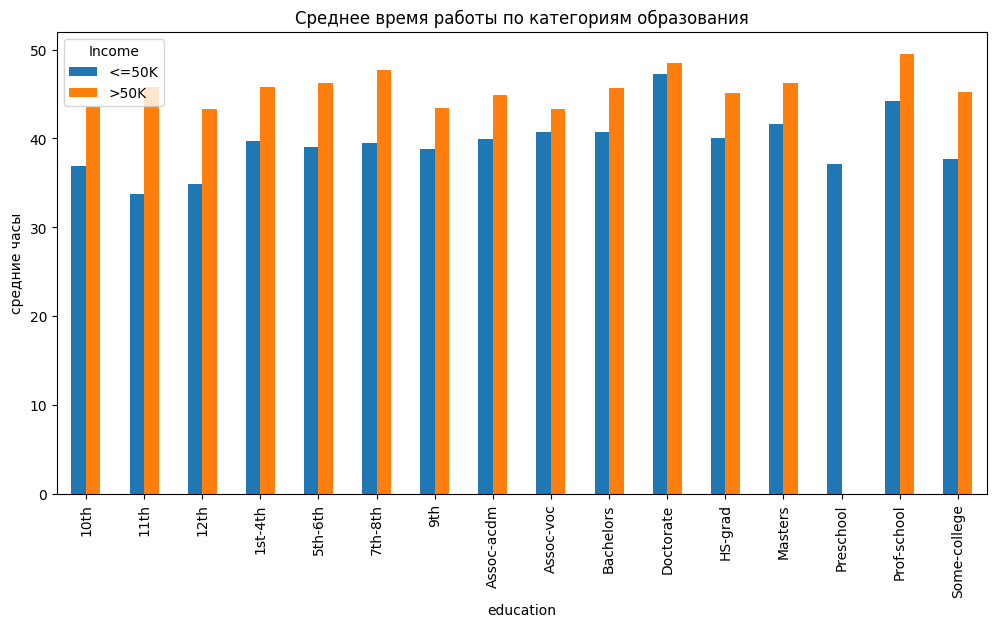

In [ ]:
bar.plot(kind="bar", figsize=(12, 6))

plt.xticks(rotation=90)
plt.ylabel("средние часы")
plt.title("Среднее время работы по категориям образования")
plt.legend(["<=50K", ">50K"], title="Income")
plt.show()

In [ ]:
bar.mean(axis=1).sort_values(ascending=False)



,0
education,
Doctorate,47.890024
Prof-school,46.878587
Masters,43.944176
7th-8th,43.588280
Bachelors,43.193035
1st-4th,42.757728
5th-6th,42.628660
HS-grad,42.551585
Assoc-acdm,42.386927


Видим, что самые трудолюбивые категории - Doctorate, Prof-school, Masters, 7th-8th, Bachelors. Все топы с точки зрения дохода входят в топ 5 самых трудолюбивых категорий. Получается, категории Doctorate, Prof-school, Masters, Bachelors наиболее привлекательны, хоть и не являются массовыми

In [ ]:
df.education.unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', '7th-8th', 'Doctorate', 'Assoc-voc', 'Prof-school',
       '5th-6th', '10th', 'Preschool', '12th', '1st-4th'], dtype=object)

In [ ]:
df.groupby('education-num')['education'].value_counts().sort_index()

,,count
education-num,education,
1,Preschool,44
2,1st-4th,149
3,5th-6th,287
4,7th-8th,556
5,9th,455
6,10th,820
7,11th,1048
8,12th,377
9,HS-grad,9834


In [ ]:
relevant_education = [
    'Doctorate',
    'Prof-school',
    'Masters',
    'Bachelors'
]

теперь посмотрим по полу, какое соотношение среди подходящих нам людей

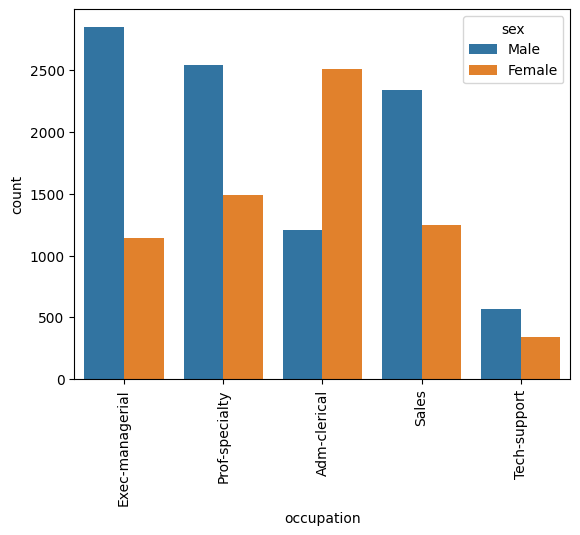

In [ ]:
plt.figure()
sns.countplot(df[df['occupation'].isin(relevant_occupations)], x='occupation', hue='sex')
plt.xticks(rotation = 90)
plt.show()

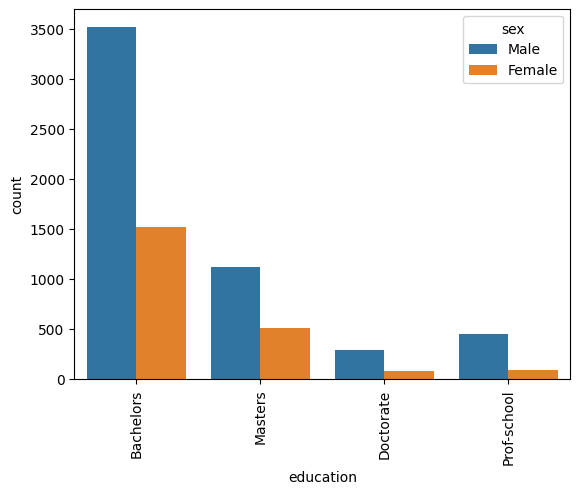

In [ ]:
plt.figure()
sns.countplot(df[df['education'].isin(relevant_education)], x='education', hue='sex')
plt.xticks(rotation = 90)
plt.show()

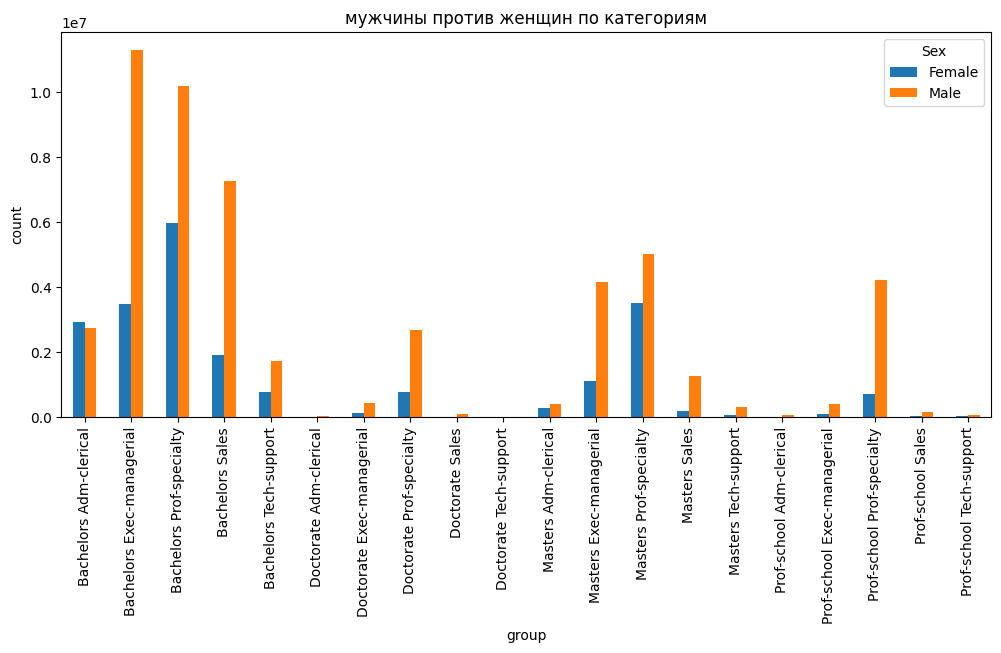

In [ ]:
df2 = df1[(df1.education.isin(relevant_education)) & (df1.occupation.isin(relevant_occupations))]

tab = (df2.groupby(["education", "occupation", "sex"])['count_people'].sum().reset_index(name="count"))

piv = tab.pivot_table(
    index=["education", "occupation"],
    columns="sex",
    values="count").reset_index()

piv["group"] = piv["education"] + " " + piv["occupation"]

piv.set_index("group")[['Female', 'Male']].plot(kind="bar",figsize=(12, 5))

plt.xticks(rotation=90)
plt.ylabel("count")
plt.title("мужчины против женщин по категориям")
plt.legend(title="Sex")
plt.show()


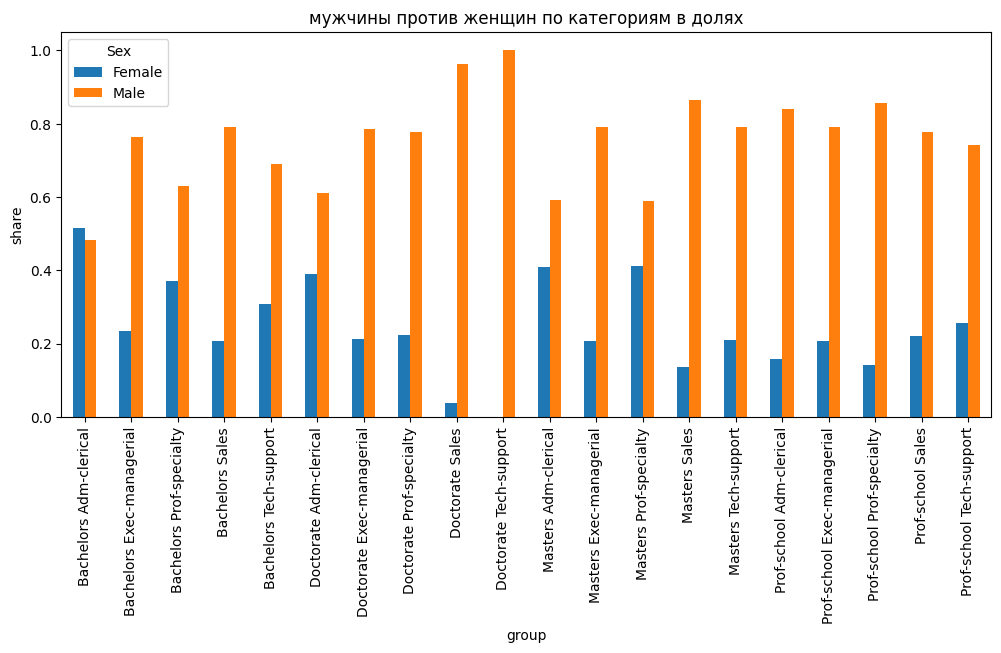

In [ ]:
piv_share = piv

piv_share[['Female', 'Male']] = (piv_share[['Female', 'Male']].div(piv_share[['Female', 'Male']].sum(axis=1), axis=0))

piv_share.set_index("group")[['Female', 'Male']].plot(kind="bar",figsize=(12, 5))

plt.xticks(rotation=90)
plt.ylabel("share")
plt.title("мужчины против женщин по категориям в долях")
plt.legend(title="Sex")

plt.show()


В большинстве категорий преобладают мужчины, исключение - Bachelors - Adm-clerical

In [ ]:
rel_edu_pop = df[df['education'].isin(relevant_education)]

rel_edu_share = rel_edu_pop['count_people'].sum()/df['count_people'].sum()
rel_edu_share

np.float64(0.2466985356892166)

In [ ]:
demo_occ_pop = (rel_occ_pop.groupby(['sex', 'race', 'marital-status'])['count_people'].sum().reset_index())
demo_occ_pop['share'] = demo_occ_pop['count_people'] / rel_occ_pop['count_people'].sum()
demo_occ_pop.sort_values('share', ascending=False).head(10)

,sex,race,marital-status,count_people,share
53,Male,White,Married-civ-spouse,63623418,0.350593
27,Female,White,Never-married,27061947,0.149123
55,Male,White,Never-married,22729856,0.125251
23,Female,White,Divorced,16755619,0.092331
25,Female,White,Married-civ-spouse,10334267,0.056946
51,Male,White,Divorced,7081081,0.039020
15,Female,Black,Never-married,5001902,0.027563
29,Female,White,Widowed,3689362,0.020330
43,Male,Black,Married-civ-spouse,3384951,0.018653
28,Female,White,Separated,2664358,0.014682


In [ ]:
demo_edu_pop = (rel_edu_pop.groupby(['sex', 'race', 'marital-status'])['count_people'].sum().reset_index())
demo_edu_pop['share'] = demo_edu_pop['count_people'] / rel_edu_pop['count_people'].sum()
demo_edu_pop.sort_values('share', ascending=False).head(10)

,sex,race,marital-status,count_people,share
49,Male,White,Married-civ-spouse,37707983,0.449920
51,Male,White,Never-married,11426881,0.136342
24,Female,White,Never-married,10337752,0.123347
20,Female,White,Divorced,4227416,0.050440
22,Female,White,Married-civ-spouse,3815687,0.045528
47,Male,White,Divorced,3565803,0.042546
32,Male,Asian-Pac-Islander,Married-civ-spouse,2076099,0.024771
38,Male,Black,Married-civ-spouse,1648318,0.019667
13,Female,Black,Never-married,1359319,0.016219
40,Male,Black,Never-married,990674,0.011820


In [ ]:
occ_pop = (rel_occ_pop.groupby('occupation')['count_people'].sum().sort_values(ascending=False))
occ_share = occ_pop / df['count_people'].sum()
occ_share

,count_people
occupation,
Prof-specialty,0.130474
Exec-managerial,0.128731
Adm-clerical,0.124804
Sales,0.119636
Tech-support,0.030529


In [ ]:
edu_pop = (rel_edu_pop.groupby('education')['count_people'].sum().sort_values(ascending=False))
edu_share = edu_pop / df['count_people'].sum()
edu_share

,count_people
education,
Bachelors,0.165587
Masters,0.051147
Prof-school,0.017588
Doctorate,0.012376


Возьмем топ 3 отрасли

In [ ]:
rel1 = rel_occ_pop[rel_occ_pop.occupation == 'Prof-specialty']
rel2 = rel_occ_pop[rel_occ_pop.occupation == 'Exec-managerial']
rel3 = rel_occ_pop[rel_occ_pop.occupation == 'Adm-clerical']

топ 4 образования

In [ ]:
edu1 = rel_edu_pop[rel_edu_pop.education == 'Bachelors']
edu2 = rel_edu_pop[rel_edu_pop.education == 'Masters']
edu3 = rel_edu_pop[rel_edu_pop.education == 'Prof-school']
edu4 = rel_edu_pop[rel_edu_pop.education == 'Doctorate']

In [ ]:
demo1 = (rel1.groupby(['sex', 'race', 'marital-status'])['count_people'].sum().reset_index())
demo1['share'] = demo1['count_people'] / rel1['count_people'].sum()
demo1.sort_values('share', ascending=False).head(10)

,sex,race,marital-status,count_people,share
46,Male,White,Married-civ-spouse,17683618,0.398948
26,Female,White,Never-married,6150882,0.138766
48,Male,White,Never-married,5789063,0.130603
22,Female,White,Divorced,3353171,0.075649
24,Female,White,Married-civ-spouse,2864384,0.064621
44,Male,White,Divorced,1525103,0.034407
33,Male,Asian-Pac-Islander,Married-civ-spouse,922201,0.020805
38,Male,Black,Married-civ-spouse,706020,0.015928
28,Female,White,Widowed,675808,0.015246
15,Female,Black,Never-married,642197,0.014488


In [ ]:
demo2 = (rel2.groupby(['sex', 'race', 'marital-status'])['count_people'].sum().reset_index())
demo2['share'] = demo2['count_people'] / rel2['count_people'].sum()
demo2.sort_values('share', ascending=False).head(10)

,sex,race,marital-status,count_people,share
42,Male,White,Married-civ-spouse,21535075,0.492415
44,Male,White,Never-married,3957655,0.090495
23,Female,White,Never-married,3604545,0.082421
19,Female,White,Divorced,3473952,0.079434
41,Male,White,Divorced,2340987,0.053528
21,Female,White,Married-civ-spouse,2325029,0.053164
33,Male,Black,Married-civ-spouse,1066969,0.024397
30,Male,Asian-Pac-Islander,Married-civ-spouse,668733,0.015291
25,Female,White,Widowed,540111,0.012350
10,Female,Black,Divorced,508984,0.011638


In [ ]:
demo3 = (rel3.groupby(['sex', 'race', 'marital-status'])['count_people'].sum().reset_index())
demo3['share'] = demo3['count_people'] / rel3['count_people'].sum()
demo3.sort_values('share', ascending=False).head(10)

,sex,race,marital-status,count_people,share
26,Female,White,Never-married,9683885,0.228397
22,Female,White,Divorced,6447778,0.152073
48,Male,White,Married-civ-spouse,5574022,0.131465
50,Male,White,Never-married,5001664,0.117966
24,Female,White,Married-civ-spouse,3338913,0.078749
15,Female,Black,Never-married,2308656,0.054450
28,Female,White,Widowed,1544381,0.036425
12,Female,Black,Divorced,1171602,0.027633
27,Female,White,Separated,927235,0.021869
46,Male,White,Divorced,922614,0.021760


В каждой отрасли выберем по 2 топа

In [ ]:
cat1 = rel_occ_pop[
    (rel_occ_pop['race'] == 'White') &
    (rel_occ_pop['marital-status'] == 'Married-civ-spouse') &
    (rel_occ_pop['sex'] == 'Male')]

cat2 = rel_occ_pop[
    (rel_occ_pop['race'] == 'White') &
    (rel_occ_pop['marital-status'] == 'Never-married') &
    (rel_occ_pop['sex'] == 'Female')]

cat3 = rel_occ_pop[
    (rel_occ_pop['race'] == 'White') &
    (rel_occ_pop['marital-status'] == 'Never-married') &
    (rel_occ_pop['sex'] == 'Male')]

cat4 = rel_occ_pop[
    (rel_occ_pop['race'] == 'White') &
    (rel_occ_pop['marital-status'] == 'Divorced') &
    (rel_occ_pop['sex'] == 'Female')]

топ 4 категории


- 1я категория: белые женатые мужчины (гражданская супруга)
- 2я категория: белые женщины, никогда не состоявшие в браке
- 3я категория: белые мужчины, никогда не состоявшие в браке
- 4я категория: белые женщины в разводе


Внутри этих категорий выберем еще и по 2 самых интересующих нас образования

In [ ]:
edu_demo1 = (cat1[cat1["education"].isin(relevant_education)].groupby(['sex', 'race', 'marital-status', 'education'])['count_people'].sum().reset_index())

edu_demo1['share'] = edu_demo1['count_people'] / edu_demo1['count_people'].sum()

edu_demo1.sort_values('share', ascending=False)


,sex,race,marital-status,education,count_people,share
0,Male,White,Married-civ-spouse,Bachelors,20076537,0.598612
2,Male,White,Married-civ-spouse,Masters,7605102,0.226758
3,Male,White,Married-civ-spouse,Prof-school,3539587,0.105538
1,Male,White,Married-civ-spouse,Doctorate,2317245,0.069092


In [ ]:
edu_demo2 = (cat2[cat2["education"].isin(relevant_education)].groupby(['sex', 'race', 'marital-status', 'education'])['count_people'].sum().reset_index())

edu_demo2['share'] = edu_demo2['count_people'] / edu_demo2['count_people'].sum()

edu_demo2.sort_values('share', ascending=False)


,sex,race,marital-status,education,count_people,share
0,Female,White,Never-married,Bachelors,7088573,0.733276
2,Female,White,Never-married,Masters,1871984,0.193647
1,Female,White,Never-married,Doctorate,392927,0.040646
3,Female,White,Never-married,Prof-school,313506,0.032431


In [ ]:
edu_demo3 = (cat3[cat3["education"].isin(relevant_education)].groupby(['sex', 'race', 'marital-status', 'education'])['count_people'].sum().reset_index())

edu_demo3['share'] = edu_demo3['count_people'] / edu_demo3['count_people'].sum()

edu_demo3.sort_values('share', ascending=False)


,sex,race,marital-status,education,count_people,share
0,Male,White,Never-married,Bachelors,7393480,0.752572
2,Male,White,Never-married,Masters,1596713,0.162527
3,Male,White,Never-married,Prof-school,462064,0.047033
1,Male,White,Never-married,Doctorate,372024,0.037868


In [ ]:
edu_demo4 = (cat4[cat4["education"].isin(relevant_education)].groupby(['sex', 'race', 'marital-status', 'education'])['count_people'].sum().reset_index())

edu_demo4['share'] = edu_demo4['count_people'] / edu_demo4['count_people'].sum()

edu_demo4.sort_values('share', ascending=False)


,sex,race,marital-status,education,count_people,share
0,Female,White,Divorced,Bachelors,2330960,0.581118
2,Female,White,Divorced,Masters,1298775,0.323790
3,Female,White,Divorced,Prof-school,194372,0.048458
1,Female,White,Divorced,Doctorate,187060,0.046635


Самые востребованные для нас категории:
- 1я категория: белые женатые мужчины (гражданская супруга)
- 2я категория: белые женщины, никогда не состоявшие в браке
- 3я категория: белые мужчины, никогда не состоявшие в браке
- 4я категория: белые женщины в разводе

с уровнями образования Bachelors и Masters


Если посмотрим на данные, в голове складывается несколько гипотез, рассмотрим некоторые из них более подробно

      Гипотеза 1

В рамках наиболее массовых и релевантных HR-категорий белые женатые мужчины с высшим образованием (Bachelors/Masters), занятые в Prof-specialty и Exec-managerial, работают статистически значимо больше часов в неделю, чем остальные выделенные демографические категории с тем же уровнем образования и в тех же профессиях.

H0: среднее hours-per-week не выше у белых женатых мужчин с высшим образованием (Bachelors/Masters), занятых в Prof-spectalty и Exec-managerial по сравнению другими демографическими категориями

H1: у белых женатых мужчин с высшим образованием(Bachelors/Masters), занятых в Prof-spectalty и Exec-managerial среднее hours-per-week выше

In [ ]:
target = df[
    (df['race'] == 'White') &
    (df['sex'] == 'Male') &
    (df['marital-status'] == 'Married-civ-spouse') &
    (df['education'].isin(['Bachelors', 'Masters'])) &
    (df['occupation'].isin(['Prof-specialty', 'Exec-managerial']))
]['hours-per-week']


In [ ]:
control = df[~((df['race'] == 'White') & (df['sex'] == 'Male') & (df['marital-status'] == 'Married-civ-spouse')) &
    (df['education'].isin(['Bachelors', 'Masters'])) &
    (df['occupation'].isin(['Prof-specialty', 'Exec-managerial']))
]['hours-per-week']

In [ ]:
len(target), len(control)

(1814, 2288)

Проверим нормальность распределений

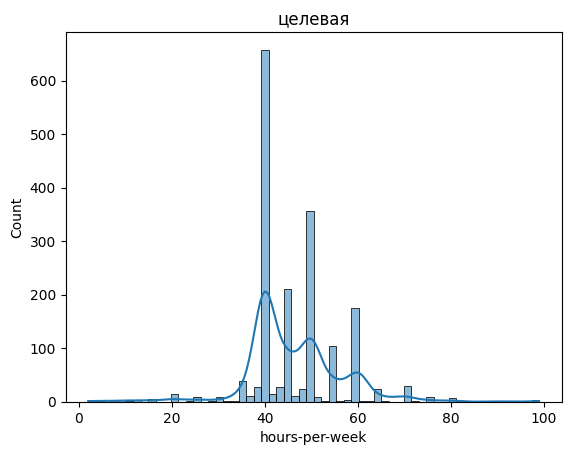

In [ ]:
sns.histplot(target, kde=True)
plt.title("целевая")
plt.show()

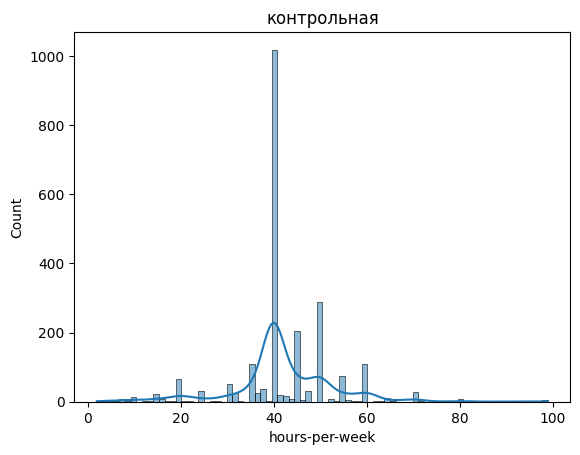

In [ ]:
sns.histplot(control, kde=True)
plt.title("контрольная")
plt.show()

In [ ]:
shapiro_target = shapiro(target)
shapiro_target

ShapiroResult(statistic=np.float64(0.889104113106549), pvalue=np.float64(3.174164946808551e-34))

In [ ]:
shapiro_control = shapiro(control)
shapiro_control

ShapiroResult(statistic=np.float64(0.879429038464377), pvalue=np.float64(6.245980673231111e-39))

pvalue < 0.05 => отклоняем гипотезы о нормальности распределения

Для ненормального распределения мы можем использовать тест Манна-Уитни

In [ ]:
mannwhitneyu(target, control, alternative='greater')


MannwhitneyuResult(statistic=np.float64(2591922.0), pvalue=np.float64(2.220422750341834e-46))

pvalue < 0.05 => отвергаем нулевую гипотезу => среднее hours-per-week НЕ не выше у белых женатых мужчин с высшим образованием (Bachelors/Masters), занятых в Prof-spectalty и Exec-managerial по сравнению другими демографическими категориями => есть статистически значимые основания принять альтернативную гипотезу:

H1: у белых женатых мужчин с высшим образованием(Bachelors/Masters), занятых в Prof-spectalty и Exec-managerial среднее hours-per-week выше

    Гипотеза 2

  Среди никогда не состоявших в браке сотрудников различия в трудолюбии (hours-per-week) между мужчинами и женщинами статистически значимы и зависят от профессии.

H0: внутри профессии распределение hours-per-week одинаково для мужчин и женщин

H1: различия присутствуют хотя бы в одной профессии

In [ ]:
df_nm = df[
    (df['marital-status'] == 'Never-married') & (df.race == 'White') &
    (df.occupation.isin(relevant_occupations))
].copy()

df_nm['group'] = df_nm.occupation + ' ' + df_nm.sex

df_nm['group'].value_counts()

,count
group,
Adm-clerical Female,862
Prof-specialty Female,560
Sales Female,552
Sales Male,527
Prof-specialty Male,482
Adm-clerical Male,398
Exec-managerial Male,345
Exec-managerial Female,323
Tech-support Male,140


Краскал, потому что больше 2

In [ ]:
groups = [
    df_nm.loc[df_nm['group'] == g, 'hours-per-week']
    for g in df_nm['group'].unique()]

kruskal(*groups)

KruskalResult(statistic=np.float64(411.83804825910767), pvalue=np.float64(4.075734769611926e-83))

Отвергаем гипотезу, что все одинаковые

In [ ]:
pairs = []
pvals = []

for occ in relevant_occupations:
    x = df_nm[(df_nm['occupation'] == occ) & (df_nm['sex'] == 'Male')]['hours-per-week']
    y = df_nm[(df_nm['occupation'] == occ) & (df_nm['sex'] == 'Female')]['hours-per-week']

    stat, p = mannwhitneyu(x, y)
    pairs.append(occ)
    pvals.append(p)

rej, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method='holm')

posthoc = pd.DataFrame({
    'occupation': pairs,
    'p_value_raw': pvals,
    'p_value_adj': pvals_adj,
    'significant': rej
}).sort_values('p_value_adj')

posthoc


,occupation,p_value_raw,p_value_adj,significant
2,Sales,1.651732e-27,8.258660e-27,True
1,Prof-specialty,8.047532e-03,3.219013e-02,True
0,Exec-managerial,1.808132e-02,4.444290e-02,True
3,Adm-clerical,2.779985e-02,4.444290e-02,True
4,Tech-support,1.481430e-02,4.444290e-02,True


Во всех случаях отклоняем гипотезу об отсутствии  отличий

Для кандидатов расы White трудолюбие (рабочие часы) систематически связано с полом вне зависимости от профессии.

Это означает, что в данной подгруппе демографические характеристики могут служить прогностическим фактором рабочей нагрузки.

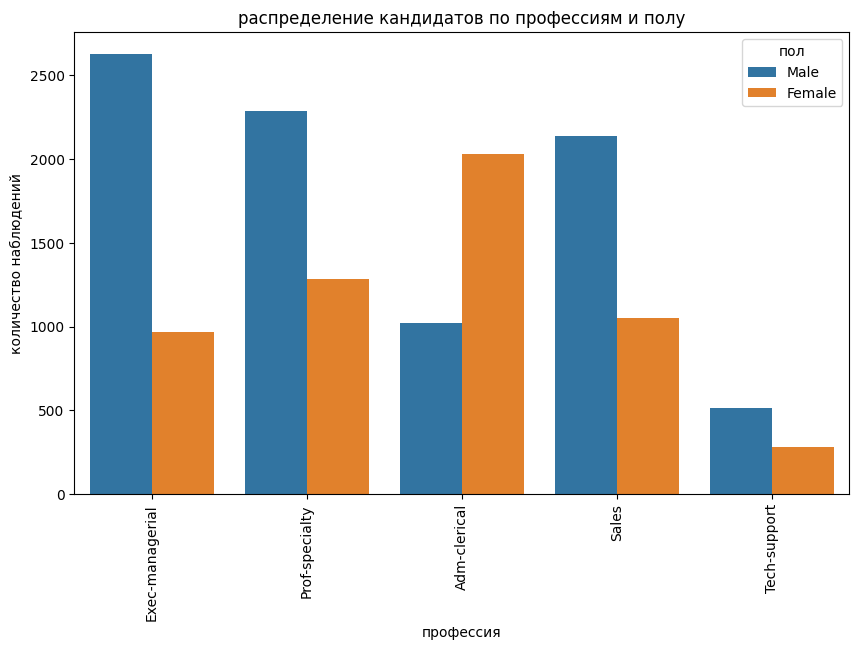

In [ ]:
dfshw = df[(df.race == 'White') & (df.occupation.isin(relevant_occupations))]

plt.figure(figsize=(10, 6))

sns.countplot(data=dfshw, x='occupation', hue='sex')

plt.title('распределение кандидатов по профессиям и полу')
plt.xlabel('профессия')
plt.ylabel('количество наблюдений')
plt.xticks(rotation=90)
plt.legend(title='пол')
plt.show()

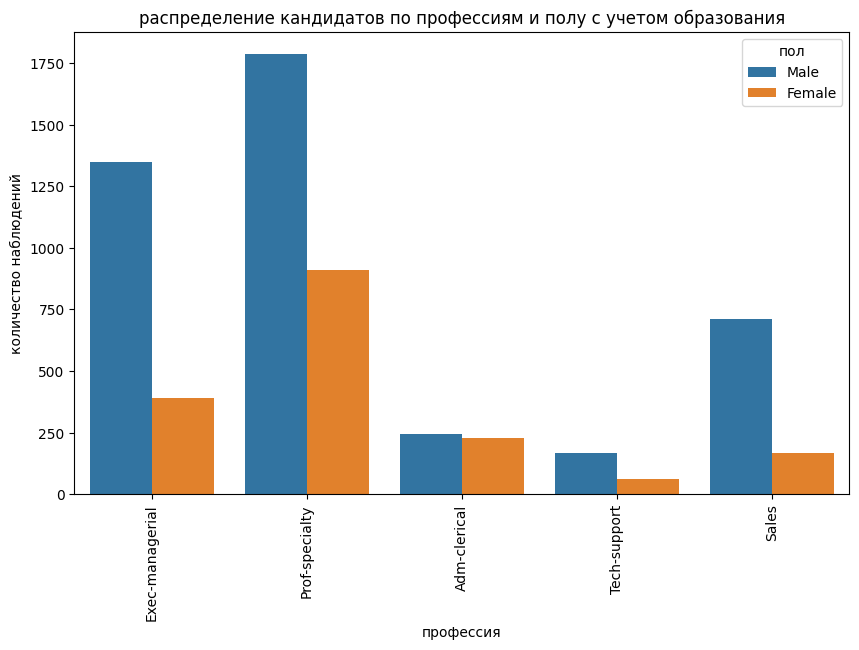

In [ ]:
dfshw = df[(df.race == 'White') & (df.education.isin(relevant_education))&(df.occupation.isin(relevant_occupations))]

plt.figure(figsize=(10, 6))

sns.countplot(data=dfshw, x='occupation', hue='sex')

plt.title('распределение кандидатов по профессиям и полу c учетом образования')
plt.xlabel('профессия')
plt.ylabel('количество наблюдений')
plt.xticks(rotation=90)
plt.legend(title='пол')
plt.show()

    гипотеза 3:
  
Внутри тoповых HR-категорий люди, со степенью Masters имеют более высокую трудовую нагрузку (hours-per-week), по сравнению с уровнем Bachelors.

H0: средние hours-per-week для Masters не больше, чем для Bachelors

H1: Masters работают больше

In [ ]:
df_h3 = df[
    (df['race'] == 'White') &
    (df['occupation'].isin(relevant_occupations)) &
    (df['education'].isin(['Bachelors', 'Masters']))
].copy()


In [ ]:
eda_h3 = (df_h3.groupby('education')['hours-per-week'].agg(['count', 'median', 'mean']))

eda_h3


,count,median,mean
education,,,
Bachelors,3831,40.0,43.264161
Masters,1381,40.0,44.750181


In [ ]:
masters = df_h3[df_h3['education'] == 'Masters']['hours-per-week']
bachelors = df_h3[df_h3['education'] == 'Bachelors']['hours-per-week']

In [ ]:
mannwhitneyu(masters, bachelors, alternative='greater')

MannwhitneyuResult(statistic=np.float64(2805102.5), pvalue=np.float64(0.0002687978976743075))

pvalue < 0,05 => отклоняем нулевую гипотезу => Masters работают больше

In [ ]:
share_over_40 = (df_h3.assign(over_40=lambda x: x['hours-per-week'] > 40).groupby('education')['over_40'].mean())

share_over_40


,over_40
education,
Bachelors,0.436440
Masters,0.483707


    гипотеза 4

In [ ]:
df4 = df.copy()
df4['hard_worker'] = (df4['hours-per-week'] > 40).astype(int)


In [ ]:
df_h4 = df4[
    (df4['race'] == 'White') &
    (df4['occupation'].isin(relevant_occupations))].copy()


In [ ]:
ct = pd.crosstab(df_h4['occupation'], df_h4['hard_worker'])
ct.columns = ['<=40', '>40']
ct

,<=40,>40
occupation,,
Adm-clerical,2590,460
Exec-managerial,1791,1804
Prof-specialty,2110,1461
Sales,1898,1294
Tech-support,610,185


In [ ]:
share_over40 = ct['>40'] / ct.sum(axis=1)
share_over40.sort_values(ascending=False)


,0
occupation,
Exec-managerial,0.501808
Prof-specialty,0.409129
Sales,0.405388
Tech-support,0.232704
Adm-clerical,0.150820


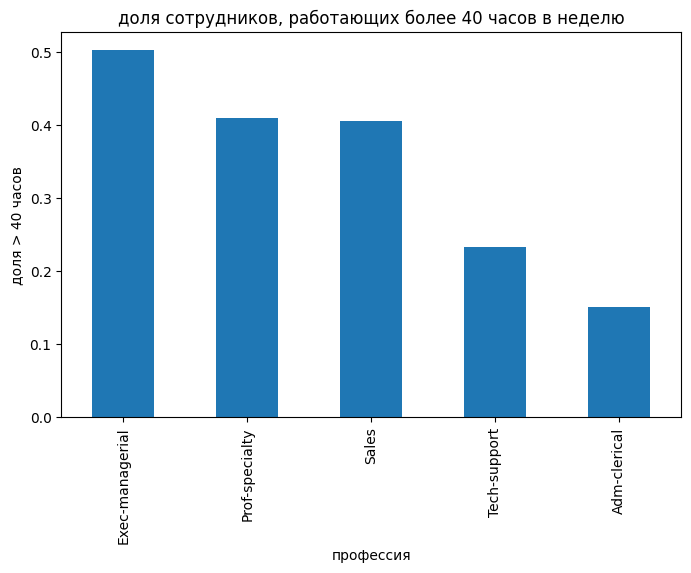

In [ ]:

share_srt = share_over40.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
share_srt.plot(kind='bar')

plt.title('доля сотрудников, работающих более 40 часов в неделю')
plt.ylabel('доля > 40 часов')
plt.xlabel('профессия')
plt.xticks(rotation=90)
plt.show()


In [ ]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(ct)

chi2, p_value


(np.float64(1004.7156885210564), np.float64(3.393416270443385e-216))

pvalue < 0,05

In [ ]:
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
expected_df

,<=40,>40
occupation,,
Adm-clerical,1932.475533,1117.524467
Exec-managerial,2277.786735,1317.213265
Prof-specialty,2262.580370,1308.419630
Sales,2022.446525,1169.553475
Tech-support,503.710836,291.289164


# Вова + Саша 2 гипотеза. EDA, capital_gain

In [ ]:
arr = list(sorted(df['capital-gain'].unique()))
min_len = float("inf")
for i in range(len(arr)):
  if i < len(arr)-2:
    min_len = min(arr[i+2] - arr[i], min_len)
min_len


np.int64(15)

Почему такое распределение capital_gain:

Для анонимизации ответов использовалась некоторая аппроксимация, которая при этом должна была сохранять распределение данных.
Данные группируются поинтервально вдоль оси значаний capital_gain, причём длина интервалов может отличаться на бОльших значениях, чтобы сконцентрировать ещё более разбросанные значения. К группам внутри интервалов применялась некоторая функция, выбирающая значение наиболее точно описывающее группу, возможно банальное среднее или медиана. В итоге, мы получаем вместо персональных значений каждого пользователя, группы пользователей имеющих усредненное значение группы.


Минимальная длина интервала, путём верхней оценки составляет 15. Значение внутри интервала может определяться при помощи некого математического оператора(медиана, среднее и т.д.), и все значения которые попали в интервал округляются до полученного числа, тем самым сохраняется фактическое распределение чисел наиболее точно. То есть изначально этот математический оператор использовался для аппроксимации распределения.

In [ ]:
def capital_gain_group(x):

    if 0<x <= 5000:
        return "small"
    elif x <= 20000:
        return "middle"
    elif 20000<x:
        return "big"

capital_gain_df = df[df['capital-gain'] > 0]
capital_gain_df['capital_gain_group'] = capital_gain_df['capital-gain'].apply(capital_gain_group)

order_list = ['small', 'middle', 'big']





/tmp/ipython-input-2679442864.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  capital_gain_df['capital_gain_group'] = capital_gain_df['capital-gain'].apply(capital_gain_group)


В параметр х можно подстваить любую фичу

<Axes: xlabel='capital_gain_group', ylabel='count'>

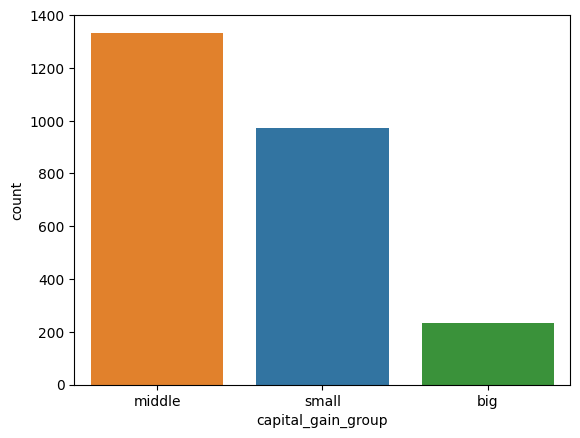

In [ ]:

sns.countplot(x='capital_gain_group', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)


<Axes: xlabel='income', ylabel='count'>

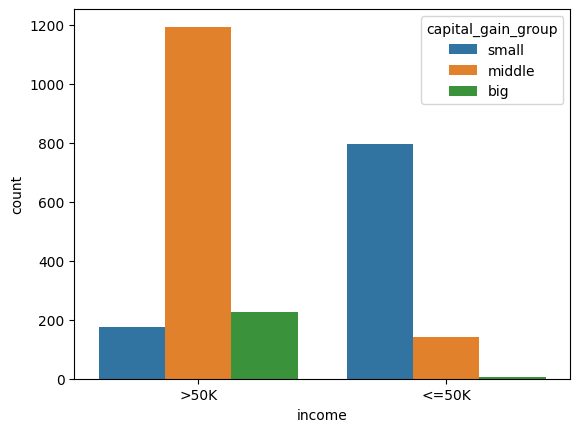

In [ ]:
sns.countplot(x='income', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Masters'),
  Text(1, 0, 'Bachelors'),
  Text(2, 0, 'HS-grad'),
  Text(3, 0, 'Some-college'),
  Text(4, 0, '11th'),
  Text(5, 0, '9th'),
  Text(6, 0, 'Assoc-voc'),
  Text(7, 0, 'Doctorate'),
  Text(8, 0, 'Prof-school'),
  Text(9, 0, 'Assoc-acdm'),
  Text(10, 0, '10th'),
  Text(11, 0, '7th-8th'),
  Text(12, 0, '5th-6th'),
  Text(13, 0, '12th'),
  Text(14, 0, 'Preschool'),
  Text(15, 0, '1st-4th')])

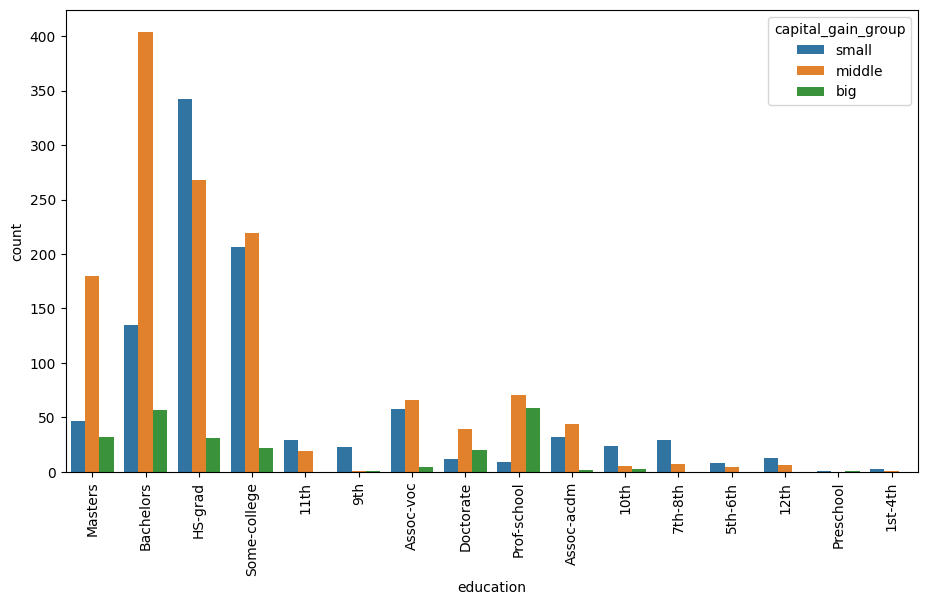

In [ ]:
plt.figure(figsize=(11, 6))

sns.countplot(x='education', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)
plt.xticks(rotation = 90)

<Axes: xlabel='capital_gain_group', ylabel='age'>

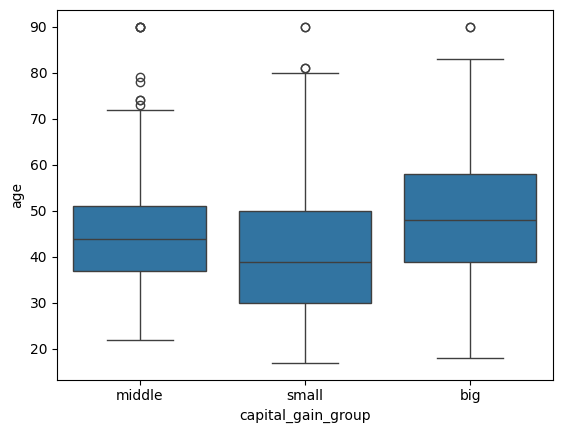

In [ ]:

sns.boxplot(data=capital_gain_df, x='capital_gain_group', y='age')

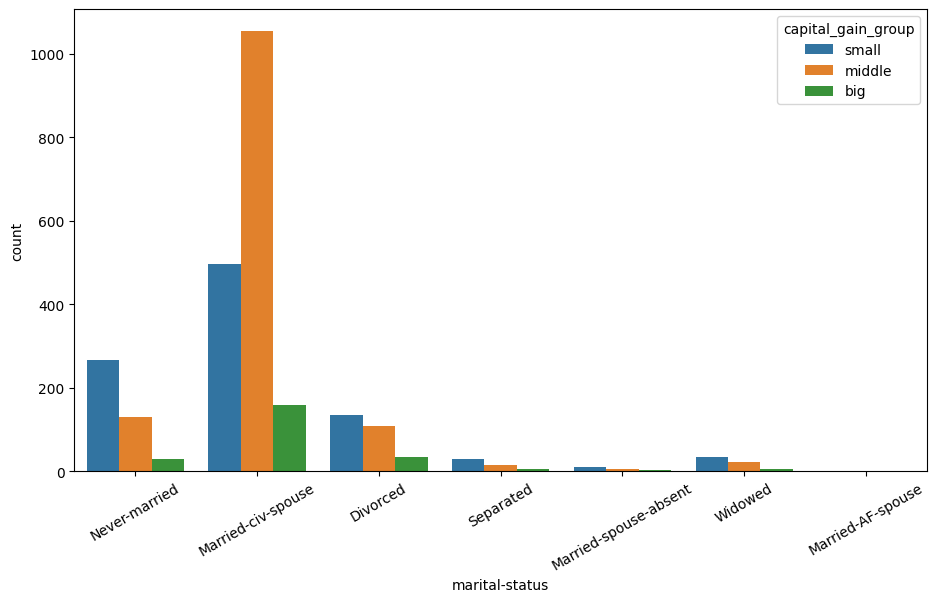

In [ ]:
plt.figure(figsize=(11, 6))
sns.countplot(x='marital-status', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)
plt.xticks(rotation = 30)
plt.show()

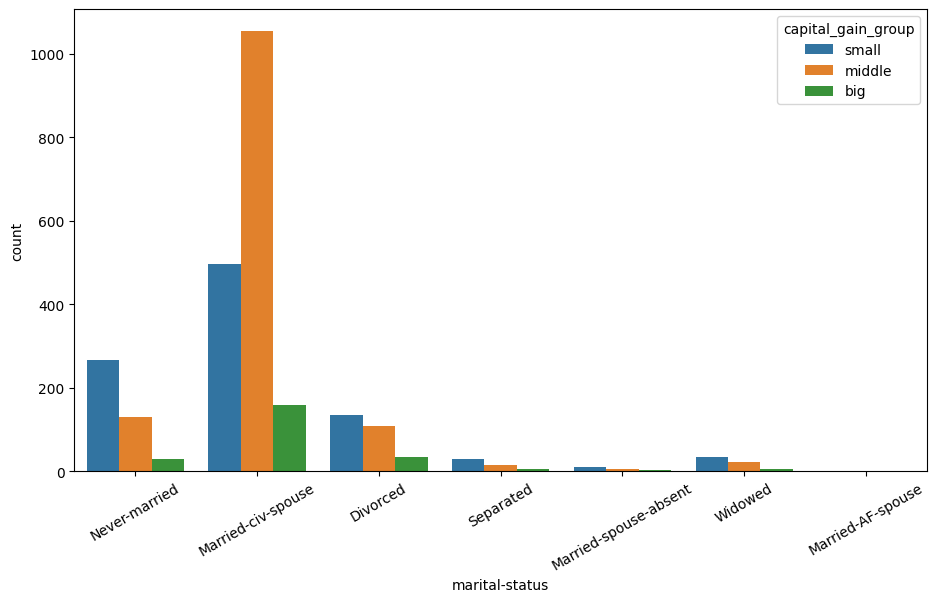

In [ ]:
plt.figure(figsize=(11, 6))
sns.countplot(x='marital-status', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)
plt.xticks(rotation = 30)
plt.show()

                                                            Гипотезы
1. Средний возраст не отличается между группами. Можно посравнивать как попарно, так и таргетированно, например: "Возраст Крупных инвесторов"

H0: Средний возраст одинаков во всех группах инвесторов (μ_small = μ_middle = μ_big)

H1: Средний возраст различается хотя бы в одной паре групп

  2.
H0: Доля мужчин одинакова во всех группах инвесторов (p_small = p_middle = p_big)

H1: Доля мужчин различается хотя бы в одной паре групп
Альтернативная версия (чтобы бахнуть другой тест при необходимости):

H0: Доля мужчин среди крупных инвесторов ≤ доле среди мелких инвесторов

H1: Доля мужчин среди крупных инвесторов > доле среди мелких инвесторов

3. Чем выше уровень образования, тем выше среди них количество крупных/средних инвесторов.

H0: Нет монотонной связи между уровнем образования и размером капитальной прибыли

H1: Существует положительная монотонная связь: более образованные люди имеют более высокий капитальный доход

4. Чем ниже уровень образования, тем больше среди них мелких инвесторов.

H0: Доля людей с низким образованием (≤ HS-grad) одинакова среди крупных и мелких инвесторов

H1: Доля людей с низким образованием среди мелких инвесторов выше, чем среди крупных

5. Что-то про семейный статус, типо наличие брака не влияет на успешность инвестора??

H0: Распределение семейного положения одинаково во всех группах инвесторов

H1: Распределение семейного положения различается между группами

6. Что-то про зарплаты в год. в целом очев, но можно и накинуть для полноты анализа.

H0: Доля высокооплачиваемых (>50K) среди крупных инвесторов ≤ доле среди мелких инвесторов

H1: Доля высокооплачиваемых (>50K) среди крупных инвесторов > доле среди мелких инвесторов

7. Крупные инвесторы работают больше.

H0: Среднее количество рабочих часов в неделю у крупных инвесторов ≤ чем у мелких инвесторов

H1: Среднее количество рабочих часов в неделю у крупных инвесторов > чем у мелких инвесторов

# Гипотеза об инвесторах (пол)

H0: Доля мужчин одинакова во всех группах инвесторов.

H1: Доля мужчин различается хотя бы в одной паре групп.

In [ ]:
print("Cумма весов по полам")
weighted_table = capital_gain_df.groupby(['capital_gain_group', 'sex'])['count_people'].sum().unstack()
print(weighted_table)
print("Общая сумма весов: ", weighted_table.sum().sum())
print()
print("Взвешенные доли")
for group in ['small', 'middle', 'big']:
    total_weight = weighted_table.loc[group].sum()
    male_weight = weighted_table.loc[group, 'Male']
    male_pct = (male_weight / total_weight) * 100
    print(group, male_pct, "% мужчин ", male_weight, total_weight)
print()
print("Доли без весов")
for group in ['small', 'middle', 'big']:
    group_data = capital_gain_df[capital_gain_df['capital_gain_group'] == group]
    total_count = len(group_data)
    male_count = (group_data['sex'] == 'Male').sum()
    male_pct = (male_count / total_count) * 100
    print(group, male_pct, " % мужчин", male_count/total_count)

Cумма весов по полам
sex                  Female      Male
capital_gain_group                   
big                  375861   2168152
middle              2696240  12236090
small               3054862   7770146
Общая сумма весов:  28301351

Взвешенные доли
small 71.77958667559415 % мужчин  7770146 10825008
middle 81.94360826475172 % мужчин  12236090 14932330
big 85.22566512042195 % мужчин  2168152 2544013

Доли без весов
small 70.33985581874357  % мужчин 0.7033985581874357
middle 82.3088455772114  % мужчин 0.823088455772114
big 84.05172413793103  % мужчин 0.8405172413793104


Проверяем гипотезу при помощи Хи квадрат теста. Обоснование: хотим оценить схожесть распределения в выборках.

In [ ]:
scale_multiplier = len(capital_gain_df) / weighted_table.values.sum() # нормировка
scaled_values = weighted_table.values * scale_multiplier # масштабирование числа наблюдений

chi2, p, dof, expected = chi2_contingency(scaled_values)

print("X² = " + str(round(chi2, 2)))
print("p-value = " + str(p))
print("Степени свободы = " + str(dof))


X² = 41.24
p-value = 1.1065640813991892e-09
Степени свободы = 2


Визуализируем распределения, смотрим на взвешенное распределение.

In [ ]:
weighted_percent = {}
for group in ['small', 'middle', 'big']:
    total = weighted_table.loc[group].sum()
    male = weighted_table.loc[group, 'Male']
    weighted_percent[group] = male / total

weighted_data = []
for group in ['small', 'middle', 'big']:
    weighted_data.append({'capital_gain_group': group, 'weighted_percent_male': weighted_percent[group]})
weighted_df = pd.DataFrame(weighted_data)

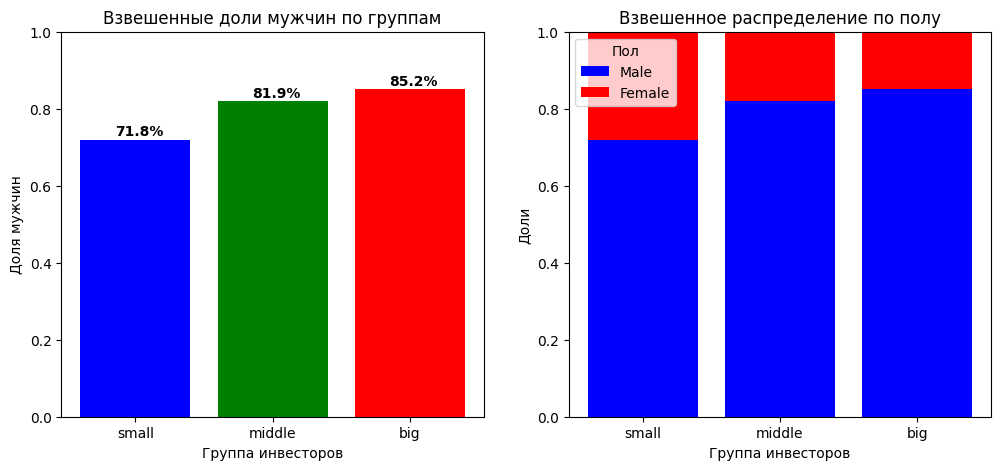

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['small', 'middle', 'big'],
           [weighted_percent['small'], weighted_percent['middle'], weighted_percent['big']],
           color=['blue', 'green', 'red'])

axes[0].set_title('Взвешенные доли мужчин по группам')
axes[0].set_xlabel('Группа инвесторов')
axes[0].set_ylabel('Доля мужчин')
axes[0].set_ylim(0, 1)

axes[0].text(-0.15, 0.73, str(round(100*weighted_percent['small'],1))+"%" , fontsize=10, fontweight='bold')
axes[0].text(0.85, 0.83, str(round(100*weighted_percent['middle'],1))+"%" , fontsize=10, fontweight='bold')
axes[0].text(1.85, 0.86, str(round(100*weighted_percent['big'],1))+"%" , fontsize=10, fontweight='bold')

male_pct = []
female_pct = []

for group in ['small','middle','big']:
    total_group = weighted_table.loc[group].sum()
    male = weighted_table.loc[group,'Male'] / total_group
    female = weighted_table.loc[group,'Female'] / total_group
    male_pct.append(male)
    female_pct.append(female)

axes[1].bar(['small','middle','big'], male_pct, color='blue', label='Male')
axes[1].bar(['small','middle','big'], female_pct, bottom=male_pct, color='red', label='Female')

axes[1].set_title('Взвешенное распределение по полу')
axes[1].set_xlabel('Группа инвесторов')
axes[1].set_ylabel('Доли')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Пол')

После оценки распределения повышаем глубину анализа. Если разница между категориями small и middle, big очевидна, то между middle и big - нет. Стоит применить z тест для пропорций, для оценки гипотезы:

H0: Нет различий между категориями Middle и Big

H1: Есть значимые различия между категориями Middle и Big



In [ ]:
print("Middle и Big сравнение:")
middle_p = weighted_table.loc['middle', 'Male'] / weighted_table.loc['middle'].sum()
big_p = weighted_table.loc['big', 'Male'] / weighted_table.loc['big'].sum()
print("Middle:", round(middle_p*100, 1),"%")
print("Big:", round(big_p*100, 1),"%")
print("Разница:", round((big_p - middle_p)*100,1),"%")

p_prob = (weighted_table.loc['middle', 'Male'] + weighted_table.loc['big', 'Male']) / (weighted_table.loc['middle'].sum() + weighted_table.loc['big'].sum())

# p - выборочная доля (с крышечкой)  = бином / n

se = np.sqrt(p_prob*(1-p_prob)
            *
           (1 / weighted_table.loc['middle'].sum() +
            1 / weighted_table.loc['big'].sum()))

z = (big_p - middle_p) / se
p_value = 2*(1 - norm.cdf(abs(z))) # значений, лежащих в левом и правом хвостах "дальше" числа z бесконечно мало
print("p-value =", p_value)

diff = big_p - middle_p
di_lower = diff - 1.96*se
di_upper = diff + 1.96*se
print("95% ДИ для разницы: [", round(di_lower*100, 3), "% ,", round(di_upper*100, 3), "% ]")

Middle и Big сравнение:
Middle: 81.9 %
Big: 85.2 %
Разница: 3.3 %
p-value = 0.0
95% ДИ для разницы: [ 3.231 % , 3.333 % ]


Bootstrap оценка разницы: 3.283 %
Bootstrap SE: 0.025 %
Bootstrap 95% ДИ: [ 3.234 % , 3.332 % ]


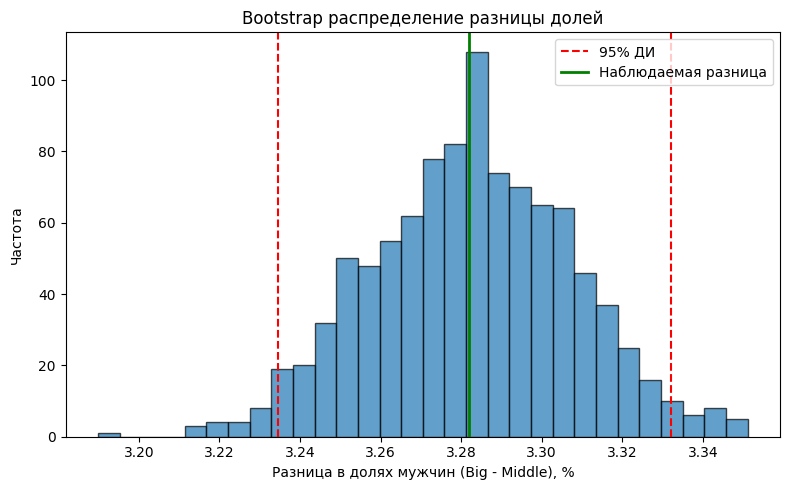

In [ ]:
n_boot = 1000
boot_diffs = []

for _ in range(n_boot):
    middle_sample = np.random.binomial(n=int(weighted_table.loc['middle'].sum()), p=middle_p, size=1)[0]
    big_sample = np.random.binomial(n=int(weighted_table.loc['big'].sum()), p=big_p, size=1)[0]
    middle_boot_p = middle_sample / weighted_table.loc['middle'].sum()
    big_boot_p = big_sample / weighted_table.loc['big'].sum()
    boot_diffs.append(big_boot_p - middle_boot_p)

boot_diffs = np.array(boot_diffs)
boot_mean = np.mean(boot_diffs)
boot_se = np.std(boot_diffs)
boot_di_lower = np.percentile(boot_diffs, 2.5)
boot_di_upper = np.percentile(boot_diffs, 97.5)

print("Bootstrap оценка разницы:", round(boot_mean*100, 3), "%")
print("Bootstrap SE:", round(boot_se*100, 3), "%")
print("Bootstrap 95% ДИ: [", round(boot_di_lower*100, 3), "% ,", round(boot_di_upper*100, 3), "% ]")

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(boot_diffs*100, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(boot_di_lower*100, color='red', linestyle='--', label='95% ДИ')
ax.axvline(boot_di_upper*100, color='red', linestyle='--')
ax.axvline(diff*100, color='green', linewidth=2, label='Наблюдаемая разница')
ax.set_xlabel('Разница в долях мужчин (Big - Middle), %')
ax.set_ylabel('Частота')
ax.set_title('Bootstrap распределение разницы долей')
ax.legend()
plt.tight_layout()
plt.show()

Bootstrap и Z-тест показали очень схожие значения, которые позволяют однозначно отклонить нулевую гипотезу и принять альтернативную: различия есть. Из этого вывода и совокупного анализа распределений получаем финальные результаты.

Бизнес выводы: По результатам аналитики предлагаем пул из нескольких различных стратегий.

1) Расширение целевой аудитории. Как можно заметить процент женщин переходящих из категории small в категорию middle сильно падает, следует собрать фокус-группу или провести опрос, чтобы выяснить реальные причины, почему женщины не инвестируют большие суммы.


2) Акцент на текущих клиентах. В результате статистических тестов, мы можем чётко определить взаимодействие, нацеленное на мужскую часть аудитории инвесторов среднего и крупного сегмента. Более того, есть значимая разница в долях мужчин в этих группах. Вывод: чем выше уровень инвестиций, тем выше доля мужчин в таких группах. В таком случае имеет смысл вводить инновации с учётом этой особенности.

Конкретные действия: продвигать при помощи маркетинговых инструментов подходящий для групп контент: агрессивные, нацеленные на высокий доход стратегии инвестирования для BIG /// готовые, автоматизированные и с умеренным риском стратегии, обучающие курсы для категории middle. Во взаимодействии с аудиторией групп middle и big будут преобладать прямой стиль, цифры, конкретные результаты.

Проверять успешность внедряемых инициатив можно при помощи A/B тестирования внедрения новых продуктов (CTR реклам, обучающих курсов и прочее) . Можно пробовать обе стратегии, в итоге следует оценить LTV по половому признаку, для определения наиболее действенной стратегии.

# Гипотеза об инвесторах (Возраст)

H0: Средний возраст одинаков во всех группах инвесторов

H1: Средний возраст различается хотя бы в одной паре групп

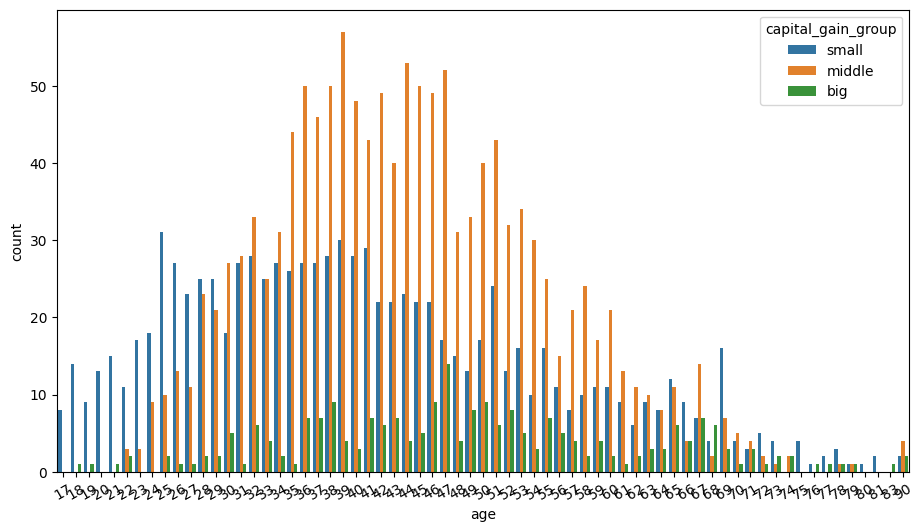

In [ ]:
plt.figure(figsize=(11, 6))
sns.countplot(x='age', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)
plt.xticks(rotation = 30)
plt.show()

Какой тест нужно применять? посмотрим на нормальность, гомогенность и размеры выборок

In [ ]:
from itertools import combinations
import scipy.stats as stats


print(stats.shapiro(capital_gain_df[capital_gain_df['capital_gain_group'] == 'small']['age']))
print(stats.shapiro(capital_gain_df[capital_gain_df['capital_gain_group'] == 'middle']['age']))
print(stats.shapiro(capital_gain_df[capital_gain_df['capital_gain_group'] == 'big']['age']))

ShapiroResult(statistic=np.float64(0.9666556753383104), pvalue=np.float64(4.081324923848091e-14))
ShapiroResult(statistic=np.float64(0.9803580686063079), pvalue=np.float64(1.6707525786508083e-12))
ShapiroResult(statistic=np.float64(0.9878007816945673), pvalue=np.float64(0.04564257158077367))


In [ ]:
capital_gain_df.groupby('capital_gain_group')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
capital_gain_group,,,,,,,,
big,232.0,49.323276,13.672223,18.0,39.0,48.0,58.0,90.0
middle,1334.0,44.323838,10.734751,22.0,37.0,44.0,51.0,90.0
small,971.0,40.998970,14.305539,17.0,30.0,39.0,50.0,90.0


Нормальность отсутсвует (хотя выборка big близка p_value=4.56%), гомогенность требует доп анализа, размеры выбора весомо разные

In [ ]:
#доп исследование на гомогенность дисперсий
groups_data = [capital_gain_df[capital_gain_df['capital_gain_group'] == 'small']['age'],
               capital_gain_df[capital_gain_df['capital_gain_group'] == 'middle']['age'],
               capital_gain_df[capital_gain_df['capital_gain_group'] == 'big']['age']]
group_names = ['small', 'middle', 'big']

levene_stat, levene_p = stats.levene(*groups_data)
print("Тест Левена: F = ", levene_stat, ", p = ", levene_p,'=> дисперсии досточно разные')

Тест Левена: F =  43.87138169842802 , p =  1.8592887009447435e-19 => дисперсии досточно разные


Классический Анова тест нельзя использвать в силу не нормальности расп, отсутсвия гомогенности и разных размеров выборок. На помощь приходит тест Анова Уэлча, он учитывает эти факторы, хотя он и менее сильный чем классический Анова тест.

https://statisticsbyjim.com/anova/welchs-anova-compared-to-classic-one-way-anova/

https://pingouin-stats.org/build/html/generated/pingouin.welch_anova.html

In [ ]:
def welch_anova(groups):#применяется для неравных выборок с разными дисперсиями
    k = len(groups)
    n_i = np.array([len(g) for g in groups])
    means = np.array([np.mean(g) for g in groups])
    VAR = np.array([np.var(g, ddof=1) for g in groups]) #ddlf это выборочные дисперсии у нас 0 так как ген совокупность

    w_i = n_i / VAR
    mean_w = np.sum(w_i * means) / np.sum(w_i)

    numerator = np.sum(w_i * (means - mean_w)**2) / (k - 1) #значимось различий между группами с учетом точности
    lambda_ = 3 * np.sum((1 - w_i/np.sum(w_i))**2 / (n_i - 1)) / (k**2 - 1)#степень неоднородности дисперсий
    denominator = 1 + 2 * lambda_ * (k - 2) / (k**2 - 1)

    F = numerator / denominator#F = (Различия между группами) / (Поправка на неоднородность)
    #F показывает насколько группы различны
    df1 = k - 1
    df2 = 1 / (3 * lambda_)
    p_value = 1 - stats.f.cdf(F, df1, df2)

    return F, df1, df2, p_value

F_stat, df1, df2, p_value = welch_anova(groups_data)
print("Welch's ANOVA: F(" , df1, ", ",df2, ") = ",F_stat, ", p = ",p_value)


print("p = " , p_value, " < 0.05 => Отвергаем H0: Средний возраст значимо различается хотя бы в одной паре групп")


Welch's ANOVA: F( 2 ,  203.17241355274552 ) =  39.1123314790473 , p =  4.218847493575595e-15
p =  4.218847493575595e-15  < 0.05 => Отвергаем H0: Средний возраст значимо различается хотя бы в одной паре групп


или можно готовой функцией с https://www.geeksforgeeks.org/machine-learning/how-to-perform-welchs-anova-in-python/

In [ ]:
!pip install pingouin

In [ ]:
import pingouin as pg

pg.welch_anova(dv='age', between='capital_gain_group', data=capital_gain_df)

,Source,ddof1,ddof2,F,p-unc,np2
0,capital_gain_group,2,609.517241,39.085623,1.068792e-16,0.036198


Мы понли что средние возраста в группах действительно не равны.Но какие конкретно группы отличаются друг от друга и насколько?следующий блок кода выполняет попарные сравнения средних значений трех групп с использованием t-теста Уэлча (Welch's t-test), который не предполагает равенства дисперсий в группах.

In [ ]:
means = [np.mean(g) for g in groups_data]

results = []
pairs = [(0, 1), (0, 2), (1, 2)]

for i, j in pairs:
    mean_diff = means[i] - means[j]

    se = np.sqrt(np.var(groups_data[i], ddof=1)/len(groups_data[i]) + np.var(groups_data[j], ddof=1)/len(groups_data[j]))#Показывает точность оценки разницы

    vi = np.var(groups_data[i], ddof=1) / len(groups_data[i])
    vj = np.var(groups_data[j], ddof=1) / len(groups_data[j])
    df_welch = (vi + vj)**2 / (vi**2/(len(groups_data[i])-1) + vj**2/(len(groups_data[j])-1))

    t_stat = mean_diff / se
    print('t-статистика:',t_stat)
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df_welch))
    print( group_names[i], ' vs ',group_names[j],'diff=',mean_diff,' p_value=',p_val)




t-статистика: -6.099458753601756
small  vs  middle diff= -3.3248679470769247  p_value= 1.3118448549676032e-09
t-статистика: -8.25650163096199
small  vs  big diff= -8.324305728186374  p_value= 2.886579864025407e-15
t-статистика: -5.29310991971488
middle  vs  big diff= -4.9994377811094495  p_value= 2.417236457663563e-07


Почему такие сложные вычисления? Проблема: В обычном t-тесте степени свободы = n1 + n2 - 2. Но это работает, только если дисперсии равны.

Решение Уэлча-Саттертуэйта: Аппроксимирует дробные степени свободы для случая неравных дисперсий.

# вывод для презы
Наиболее платёжеспособной аудиторией являются клиенты в возрасте 35–55 лет с уровнями capital gain middle и big. Фокус на данном сегменте, при одновременном развитии возрастной группы 25–35 лет, позволит максимизировать LTV и повысить общую эффективность продуктовой и маркетинговой стратегии.

Расширенная версия
1) Фокус на наиболее платёжеспособной возрастной группе

Анализ распределения capital gain по возрасту показывает, что наибольшая концентрация клиентов со средним и высоким приростом капитала (middle и big) приходится на возрастной диапазон 35–55 лет. В данном интервале наблюдается пик инвестиционной активности и устойчивый рост накопленного капитала.

Вывод: возрастная группа 35–55 лет является ключевой с точки зрения платёжеспособности и должна рассматриваться как приоритетная для продвижения высокомаржинальных продуктов.


2) Развитие потенциально платёжеспособного сегмента

В возрастной группе 25–35 лет наблюдается переход клиентов из категории small в middle, что указывает на рост доходов и формирование инвестиционного поведения.

Вывод: данный сегмент не является максимально платёжеспособным в текущий момент, однако обладает высоким потенциалом роста и формирует будущую базу клиентов middle и big сегментов.


3) Снижение приоритета для низкоплатёжеспособных групп

Для возрастных категорий до 25 лет и старше 60 лет характерно доминирование группы small и низкая доля клиентов с высоким приростом капитала.

Вывод: данные сегменты не являются приоритетными для продвижения продуктов с высоким чеком и требуют минимальных маркетинговых затрат.

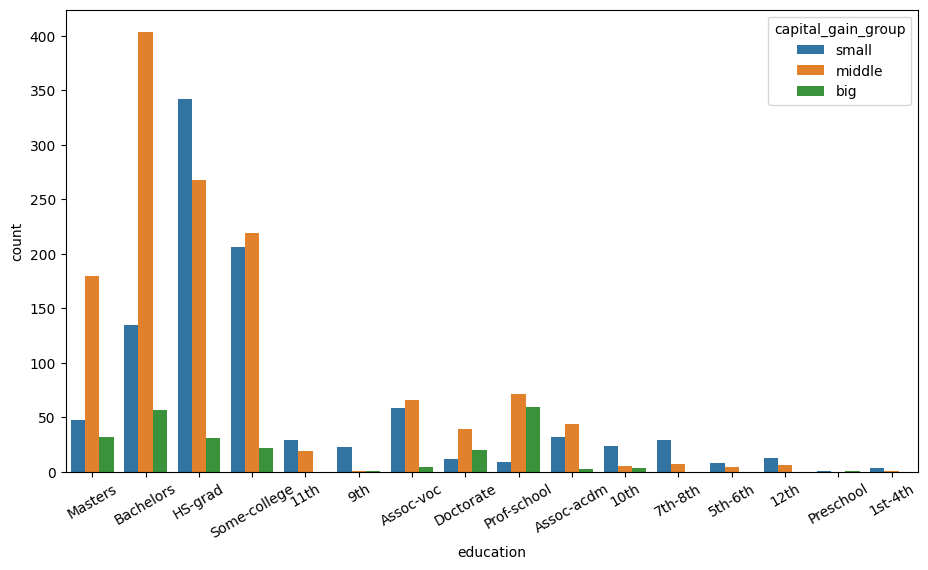

In [ ]:
plt.figure(figsize=(11, 6))
sns.countplot(x='education', hue='capital_gain_group', data=capital_gain_df, hue_order=order_list)
plt.xticks(rotation = 30)
plt.show()

H0: Нет связи между уровнем образования и размером капитальной прибыли H1: Существует связь: более образованные люди имеют более высокий капитальный доход

In [ ]:
import pandas as pd
from scipy.stats import kruskal

gain_map = {'small': 1, 'middle': 2, 'big': 3}
capital_gain_df['gain_rank'] = capital_gain_df['capital_gain_group'].map(gain_map)

groups = []

for education, df_group in capital_gain_df.groupby('education'):
    ranks = df_group['gain_rank'].dropna()

    if len(ranks) > 1:
        groups.append(ranks.values)
stat, p = kruskal(*groups)

print('H =',stat, 'p-value =', p)


H = 418.57387366784786 p-value = 8.5933672005443e-80


/tmp/ipython-input-1513034399.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  capital_gain_df['gain_rank'] = capital_gain_df['capital_gain_group'].map(gain_map)


Тест показывает, что распределения capital_gain_group различаются между уровнями образования. существует сильная статистически значимая связь между уровнем образования и размером капитального дохода. Отвергаем Н0

При таком размере выборки p-value почти всегда будет маленьким, поэтому важен размер эффекта.приближение для Kruskal–Wallis:

In [ ]:
n = len(capital_gain_df)
k = capital_gain_df['education'].nunique()

eta_sq = (stat - k + 1) / (n - k)
eta_sq


np.float64(0.16008483683770244)

эффект большой:
# Бизнес выводы

1)Люди с высшим и поствысшим образованием:

значительно чаще попадают в middle и big

доля small заметно ниже

2)Люди без завершённого среднего:

почти полностью сосредоточены в small

крайне редко достигают крупных капитальных доходов

вывод: Образование работает как фильтр доступа к инструментам, навыкам и возможностям инвестирования

Анализ с помощью теста Краскела–Уоллиса показал крайне сильную статистически значимую связь между уровнем образования и размером капитального дохода (H = 418.6, p < 10⁻⁷⁹). Более высокий уровень образования ассоциирован с заметно более высокими категориями капитальной прибыли. Результат имеет не только статистическую, но и практическую значимость и может быть использован для клиентской сегментации, продуктовой стратегии и финансового скоринга.



# ЕГОР И ВИТАЛЯ

In [ ]:
import pandas as pd

cols = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv("data.csv", header=None, names=cols)

obj = df.select_dtypes("object").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

df["fnlwgt"] = pd.to_numeric(df["fnlwgt"], errors="coerce")

df = df[df["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])].copy()
df = df[df["fnlwgt"].gt(0) & df["marital-status"].notna()].copy()
df["corp"] = (df["workclass"] == "Self-emp-inc").astype(int)

tab_w = (
    df.groupby(["marital-status", "corp"], observed=True)["fnlwgt"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
)

res = (
    tab_w.div(tab_w.sum(axis=1), axis=0)
         .rename(columns={0: "p_noncorp", 1: "p_corp"})
         .sort_values("p_corp", ascending=False)
)

res


corp,p_noncorp,p_corp
marital-status,,
Married-civ-spouse,0.664314,0.335686
Separated,0.734755,0.265245
Widowed,0.737814,0.262186
Divorced,0.742063,0.257937
Never-married,0.772916,0.227084
Married-spouse-absent,0.862890,0.137110
Married-AF-spouse,1.000000,0.000000


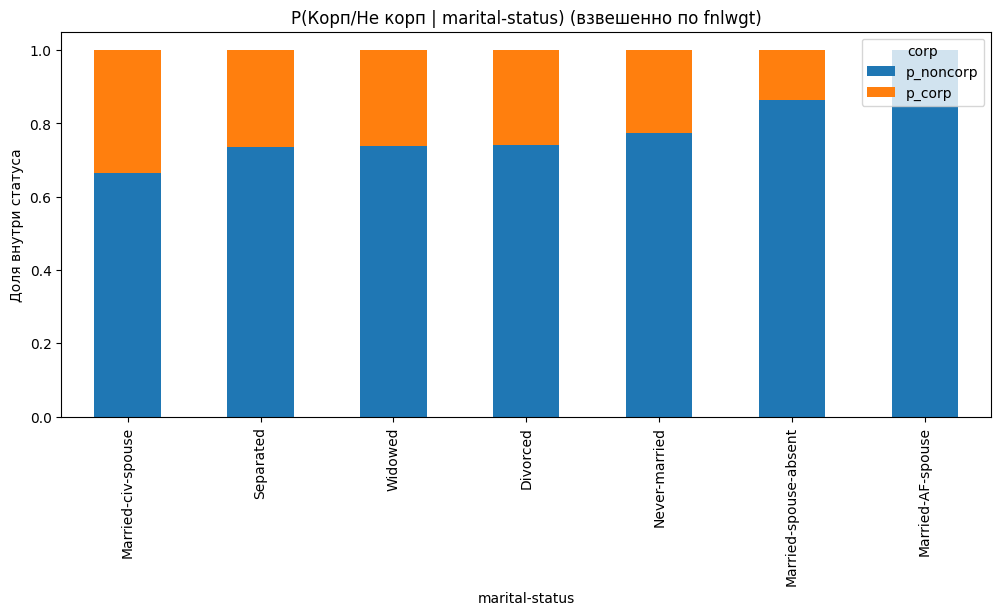

In [ ]:
import matplotlib.pyplot as plt

ax = res[["p_noncorp", "p_corp"]].plot(kind="bar", stacked=True, figsize=(12, 5))
ax.set_xlabel("marital-status")
ax.set_ylabel("Доля внутри статуса")
ax.set_title("P(Корп/Не корп | marital-status) (взвешенно по fnlwgt)")
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

cols = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv("data.csv", header=None, names=cols)

obj = df.select_dtypes("object").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

df["fnlwgt"] = pd.to_numeric(df["fnlwgt"], errors="coerce")

df = df[df["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])].copy()
df = df[df["fnlwgt"].gt(0) & df["marital-status"].notna()].copy()
df["corp"] = (df["workclass"] == "Self-emp-inc").astype(int)

tab_w = (
    df.groupby(["marital-status", "corp"], observed=True)["fnlwgt"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
)

chi2, p_value, _, _ = chi2_contingency(tab_w.values)

print(f"chi2 = {chi2:.4f}")
print(f"p_value = {p_value:.6g}")


chi2 = 6566879.6217
p_value = 0
dof = 6


In [ ]:
import pandas as pd

cols = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv("data.csv", header=None, names=cols)

obj = df.select_dtypes("object").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

df[["fnlwgt", "education-num"]] = df[["fnlwgt", "education-num"]].apply(pd.to_numeric, errors="coerce")

df = df[df["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])].copy()
df = df[df["fnlwgt"].gt(0) & df["education-num"].notna()].copy()
df["corp"] = (df["workclass"] == "Self-emp-inc").astype(int)

tab_w = (
    df.groupby(["education-num", "corp"], observed=True)["fnlwgt"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
)

res = (
    tab_w.div(tab_w.sum(axis=1), axis=0)
         .rename(columns={0: "p_noncorp", 1: "p_corp"})
)

res


corp,p_noncorp,p_corp
education-num,,
2,0.878244,0.121756
3,0.834157,0.165843
4,0.854946,0.145054
5,0.766360,0.233640
6,0.783391,0.216609
7,0.845996,0.154004
8,0.770002,0.229998
9,0.756597,0.243403
10,0.669834,0.330166


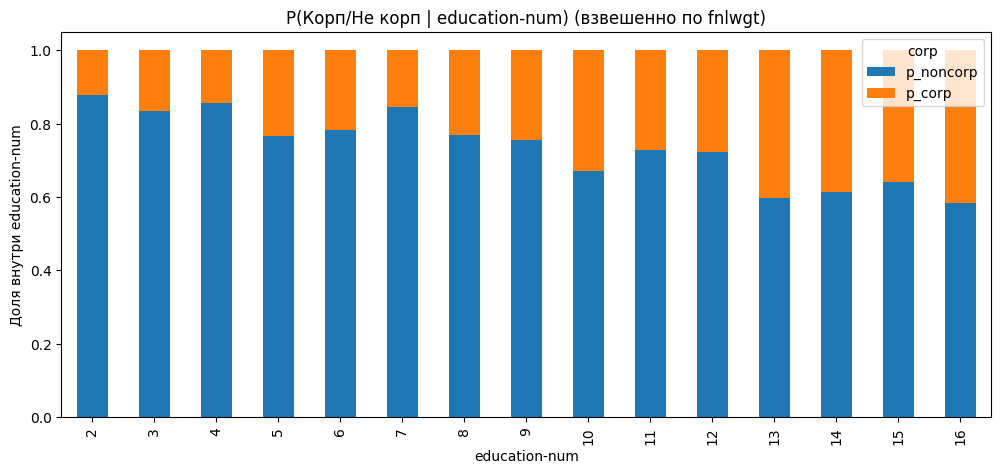

In [ ]:
import matplotlib.pyplot as plt

ax = res[["p_noncorp", "p_corp"]].plot(kind="bar", stacked=True, figsize=(12, 5))
ax.set_xlabel("education-num")
ax.set_ylabel("Доля внутри education-num")
ax.set_title("P(Корп/Не корп | education-num) (взвешенно по fnlwgt)")
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

cols = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv("data.csv", header=None, names=cols)

obj = df.select_dtypes("object").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

df[["fnlwgt", "education-num"]] = df[["fnlwgt", "education-num"]].apply(pd.to_numeric, errors="coerce")

df = df[df["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])].copy()
df = df[df["fnlwgt"].gt(0) & df["education-num"].notna()].copy()
df["corp"] = (df["workclass"] == "Self-emp-inc").astype(int)

tab_w = (
    df.groupby(["education-num", "corp"], observed=True)["fnlwgt"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
)

chi2, p_value, _, _ = chi2_contingency(tab_w.values)

print(f"chi2 = {chi2:.4f}")
print(f"p_value = {p_value:.6g}")


chi2 = 17719474.2831
p_value = 0
dof = 14


In [ ]:
import pandas as pd

cols = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv("data.csv", header=None, names=cols)
obj = df.select_dtypes("object").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

df[["fnlwgt", "education-num"]] = df[["fnlwgt", "education-num"]].apply(pd.to_numeric, errors="coerce")

df = df[df["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])].copy()
df = df[df["fnlwgt"].gt(0) & df["fnlwgt"].notna()].copy()

df["corp"] = (df["workclass"] == "Self-emp-inc").astype(int)
df["married2"] = df["marital-status"].apply(lambda x: "Married" if "Married" in x else "Not married")

gcols = ["sex", "race", "education-num", "married2"]

tab = (
    df.groupby(gcols + ["corp"], observed=True)["fnlwgt"]
      .sum()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
)

res = tab.reset_index().rename(columns={0: "w_noncorp", 1: "w_corp"})

n_df = df.groupby(gcols, observed=True).size().reset_index(name="n")
res = res.merge(n_df, on=gcols, how="left")

res = res[res["n"] >= 30].copy()

Wc = res["w_corp"].sum()
Wn = res["w_noncorp"].sum()
res["share_among_corp"] = res["w_corp"] / Wc
res["share_among_noncorp"] = res["w_noncorp"] / Wn

top10_corp = (
    res.sort_values("share_among_corp", ascending=False)
       .head(10)[gcols + ["share_among_corp", "n"]]
       .reset_index(drop=True)
)

top10_noncorp = (
    res.sort_values("share_among_noncorp", ascending=False)
       .head(10)[gcols + ["share_among_noncorp", "n"]]
       .reset_index(drop=True)
)

top10_corp, top10_noncorp


(    sex   race  education-num     married2  share_among_corp    n
 0  Male  White             13      Married          0.208901  417
 1  Male  White              9      Married          0.177173  706
 2  Male  White             10      Married          0.165022  402
 3  Male  White             15      Married          0.066733  160
 4  Male  White             14      Married          0.055381  114
 5  Male  White              9  Not married          0.052153  229
 6  Male  White             13  Not married          0.039937  112
 7  Male  White             10  Not married          0.039577  135
 8  Male  White             16      Married          0.030016   56
 9  Male  White             11      Married          0.022809   84,
       sex   race  education-num     married2  share_among_noncorp    n
 0    Male  White              9      Married             0.249966  706
 1    Male  White             10      Married             0.113689  402
 2    Male  White             13      Married 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv("data.csv", header=None)
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip()

df["fnlwgt"] = pd.to_numeric(df["fnlwgt"], errors="coerce")
df["capital-gain"] = pd.to_numeric(df["capital-gain"], errors="coerce")

df_self = df[df["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])].copy()
df_self["Y"] = (df_self["workclass"] == "Self-emp-inc").astype(int)

print("Размер подвыборки:", len(df_self))
print("Не корп:", (df_self["Y"] == 0).sum())
print("Корп:", (df_self["Y"] == 1).sum())


def weighted_quantile(x, w, q):
    x = np.asarray(x)
    w = np.asarray(w)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[m], w[m]
    if len(x) == 0:
        return np.nan
    idx = np.argsort(x)
    x, w = x[idx], w[idx]
    cw = np.cumsum(w) / np.sum(w)
    return np.interp(q, cw, x)

df_sex = df_self.dropna(subset=["sex", "fnlwgt"]).copy()

female = df_sex[df_sex["sex"] == "Female"]
male   = df_sex[df_sex["sex"] == "Male"]

p_female = np.average(female["Y"], weights=female["fnlwgt"])
p_male   = np.average(male["Y"], weights=male["fnlwgt"])

print("\nP(Self-emp-inc | Женщины):", p_female)
print("P(Self-emp-inc | Мужчины):", p_male)

plt.figure(figsize=(6,4))
plt.bar(["Женщины", "Мужчины"], [p_female, p_male], alpha=0.75)
plt.ylabel("Вероятность корп самозанятости")
plt.title("Корпоративная самозанятость по полу (взвешенно)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

tab_sex = df_sex.pivot_table(
    values="fnlwgt",
    index="sex",
    columns="Y",
    aggfunc="sum",
    fill_value=0
).reindex(index=["Female", "Male"], columns=[0,1], fill_value=0)

print("\nВзвешенная таблица (пол × корп):")
print(tab_sex)

chi2_sex, p_sex, dof_sex, exp_sex = chi2_contingency(tab_sex.values)

print("χ² =", chi2_sex)
print("p-value =", p_sex)

df_cg = df_self.dropna(subset=["capital-gain", "fnlwgt"]).copy()
df_cg["gain_pos"] = (df_cg["capital-gain"] > 0).astype(int)

g0 = df_cg[df_cg["Y"] == 0]
g1 = df_cg[df_cg["Y"] == 1]

p_gain0 = np.average(g0["gain_pos"], weights=g0["fnlwgt"])
p_gain1 = np.average(g1["gain_pos"], weights=g1["fnlwgt"])

print("\nP(capital-gain > 0 | не корп):", p_gain0)
print("P(capital-gain > 0 | корп):", p_gain1)

plt.figure(figsize=(6,4))
plt.bar(["Не корп", "Корп"], [p_gain0, p_gain1], alpha=0.75)
plt.ylabel("Вероятность capital-gain > 0")
plt.title("Наличие дохода от капитала (взвешенно)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

tab_gain = df_cg.pivot_table(
    values="fnlwgt",
    index="gain_pos",
    columns="Y",
    aggfunc="sum",
    fill_value=0
).reindex(index=[0,1], columns=[0,1], fill_value=0)

print("\nВзвешенная таблица (capital-gain>0 × корп):")
print(tab_gain)

chi2_gain, p_gain, dof_gain, exp_gain = chi2_contingency(tab_gain.values)

print("χ² =", chi2_gain)
print("p-value =", p_gain)


df_cg["log_gain"] = np.log1p(df_cg["capital-gain"])

g0 = df_cg[df_cg["Y"] == 0]
g1 = df_cg[df_cg["Y"] == 1]

plt.figure(figsize=(10,5))
plt.hist(
    g0["log_gain"], bins=60, weights=g0["fnlwgt"],
    density=True, alpha=0.6, label="Не корп"
)
plt.hist(
    g1["log_gain"], bins=60, weights=g1["fnlwgt"],
    density=True, alpha=0.6, label="Корп"
)
plt.xlabel("log(1 + capital-gain)")
plt.ylabel("Плотность")
plt.title("Распределение capital-gain (взвешенно)")
plt.legend()
plt.tight_layout()
plt.show()


pos = df_cg[df_cg["capital-gain"] > 0]

med0 = weighted_quantile(
    pos[pos["Y"] == 0]["capital-gain"],
    pos[pos["Y"] == 0]["fnlwgt"], 0.5
)
med1 = weighted_quantile(
    pos[pos["Y"] == 1]["capital-gain"],
    pos[pos["Y"] == 1]["fnlwgt"], 0.5
)

print("\nВзвешенная медиана capital-gain (если > 0):")
print("Не корп:", med0)
print("Корп:", med1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_sr = df_self.dropna(
    subset=["sex", "race", "education-num", "fnlwgt"]
).copy()


df_sr["edu_group"] = pd.NA
df_sr.loc[df_sr["education-num"].between(8, 11), "edu_group"] = "Education 8–11"
df_sr.loc[df_sr["education-num"].between(12, 16), "edu_group"] = "Education 12–16"


df_sr = df_sr.dropna(subset=["edu_group"])


top_races = (
    df_sr.groupby("race")["fnlwgt"]
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index
)

df_sr["race_grp"] = np.where(
    df_sr["race"].isin(top_races),
    df_sr["race"],
    "Other"
)


prob_sr = (
    df_sr
    .groupby(["edu_group", "race_grp", "sex"])
    .apply(lambda g: np.average(g["Y"], weights=g["fnlwgt"]))
    .reset_index(name="P_inc")
)

print("\nВзвешенные вероятности P(Self-emp-inc | sex, race, education):")
print(prob_sr)


for edu in prob_sr["edu_group"].unique():

    sub = prob_sr[prob_sr["edu_group"] == edu]
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=sub,
        x="race_grp",
        y="P_inc",
        hue="sex",
        errorbar=None
    )

    plt.xlabel("Раса")
    plt.ylabel("P(Self-emp-inc)")
    plt.title(f"Корпоративная самозанятость по полу и расе\n{edu} (взвешенно)")
    plt.ylim(0, 1)
    plt.legend(title="Пол")
    plt.show()

    heat = sub.pivot(
        index="sex",
        columns="race_grp",
        values="P_inc"
    )

    plt.figure(figsize=(8,3))
    sns.heatmap(
        heat,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    plt.title(f"P(Self-emp-inc | sex, race)\n{edu}")
    plt.show()

1) Использование весов fnlwgt

В датасете Adult переменная fnlwgt отражает вес наблюдения и показывает, какое число людей в генеральной совокупности соответствует каждой записи. Поскольку данные получены в результате выборочного обследования и отдельные группы населения представлены в выборке неравномерно, использование весов позволяет получать более корректные оценки долей и распределений. В рамках работы fnlwgt применялся при построении таблиц сопряжённости и визуализаций в тех случаях, когда целью было оценить распространённость признаков и структуру изучаемой совокупности, а не только характеристики исходного набора наблюдений.

2) Статистические гипотезы и методы

Анализ проводился на подвыборке предпринимателей, включающей наблюдения с workclass в множестве {Self-emp-inc, Self-emp-not-inc}. Для удобства был введён бинарный индикатор Y, где Y = 1 соответствует Self-emp-inc, а Y = 0 — Self-emp-not-inc.

В рамках первой гипотезы проверялась связь между полом и типом предпринимательства. Нулевая гипотеза состояла в том, что переменные sex и Y независимы, альтернативная — в наличии зависимости между ними. Для проверки использовался χ²‑тест независимости для таблицы 2×2, а при малых ожидаемых частотах — точный тест Фишера. В качестве меры эффекта рассматривались отношение шансов с 95% доверительным интервалом и коэффициент Cramer’s V.

Для анализа связи дохода от капитала с типом предпринимательства, учитывая высокую долю нулевых значений переменной capital.gain, проверка была разделена на две части. Сначала анализировалась вероятность наличия дохода от капитала. Для этого была введена бинарная переменная gain_pos = 1(capital.gain > 0), и проверялась гипотеза о её независимости от Y с использованием χ²‑теста или теста Фишера. Эффект оценивался через отношение шансов и коэффициент Cramer’s V.

Во второй части рассматривались только наблюдения с положительными значениями capital.gain. Проверялась гипотеза о равенстве распределений capital.gain в группах Y = 0 и Y = 1. В качестве статистического критерия использовался непараметрический тест Манна–Уитни. Эффект описывался сравнением медианных значений и визуальным анализом распределений в шкале log1p.

3) Интерпретация результатов и прикладные выводы

Полученные результаты показывают, что предприниматели не являются однородной группой и различаются по вероятности принадлежности к категории Self-emp-inc, которую можно интерпретировать как более формализованный или крупный тип бизнеса. Это создаёт основу для сегментации клиентов и более точной настройки банковских продуктов.

Пол оказался статистически значимо связан с типом предпринимательства: среди мужчин доля Self-emp-inc выше, чем среди женщин. При этом сила связи невелика, что указывает на ограниченную практическую ценность данного признака в качестве самостоятельного критерия сегментации.

Связь между capital.gain и типом предпринимательства выражена существенно сильнее. Для группы Self-emp-inc выше вероятность наличия положительного дохода от капитала, а среди тех, у кого такой доход имеется, его типичный размер также больше. Эти различия могут рассматриваться как косвенный индикатор более высокой инвестиционной активности и потенциально более сложных финансовых потребностей у корпоративных самозанятых.

In [ ]:
!bash

bash: cannot set terminal process group (429): Inappropriate ioctl for device
bash: no job control in this shell


/content# ^C


In [ ]:
!mkdir my_project

In [ ]:
%cd my_project

/content/my_project


In [ ]:
!touch README.md

In [ ]:
!echo "Этот проект: Глодя Мария" > README.md

In [ ]:
!cat README.md

Этот проект: Глодя Мария


In [ ]:
import pickle

In [ ]:
# Скачаем наш датасет
! wget https://www.dropbox.com/s/ofr99e7skcd515m/telecom_churn.csv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Считаем наш датасет при помощи библиотеки pandas
data = pd.read_csv('telecom_churn.csv')

X = data.drop(columns='Churn')
y = data['Churn']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=12)

def make_scores(y_valid, preds_valid):
    # Посчитаем метрики для нашего алгоритма
    print(f'Accuracy  = {accuracy_score(y_valid, preds_valid)}')
    print(f'Precision = {precision_score(y_valid, preds_valid)}')
    print(f'Recall    = {recall_score(y_valid, preds_valid)}')

--2025-12-19 14:19:33--  https://www.dropbox.com/s/ofr99e7skcd515m/telecom_churn.csv
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6017:18::a27d:212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/t0vxmjim9sdzqhaw3g2qs/telecom_churn.csv?rlkey=qlwbfmma1vfo24b0j6025wc4h [following]
--2025-12-19 14:19:33--  https://www.dropbox.com/scl/fi/t0vxmjim9sdzqhaw3g2qs/telecom_churn.csv?rlkey=qlwbfmma1vfo24b0j6025wc4h
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc7aea443a4afb2e082e68944bac.dl.dropboxusercontent.com/cd/0/inline/C3U0_z1QskKwIAMGpUjB36qKeDQ_tsxqjhaMZxPinvag46QSsLqk3O-doVVrTJmv7qE1H_a-cz5iPnAMnp_L5b70jdXOogQI5KGyZ9np5226uuSNxUCCxkOHxRR44pWEuDxjNkLolCByLCPiOoD4s420/file# [following]
--2025-12-19 14:19:34--  https://uc7aea443a4afb2e082e68944bac.dl.dropboxusercontent.co

In [ ]:
knn_first = KNeighborsClassifier(n_neighbors=5, p=1, metric='minkowski')

In [ ]:
model_path = "/content/my_project/first_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(knn_first, f)